# Imports

In [8]:
!pip install keras-tuner


   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   ---------------------------------------- 2/2 [keras-tuner]




[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from Utils.utils import loadData, reseed_grid_picker
from sklearn.model_selection import train_test_split
import pandas as pd
import keras_tuner as kt
from tqdm import tqdm
import os

# Load Dataset

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split

# Keep the class-to-number mapping consistent across both folders.
train_images, train_targets, labels = loadData("train")
test_images, test_targets, _ = loadData("test", labels)

# Combine all labeled images before creating the assignment splits.
all_x = np.concatenate([train_images, test_images], axis=0)
all_y = np.concatenate([train_targets, test_targets], axis=0)

del train_images, train_targets, test_images, test_targets

# 70% training, 30% reserved for validation and testing.
train_x, remaining_x, train_y, remaining_y = train_test_split(
    all_x,
    all_y,
    test_size=0.30,
    random_state=42,
    stratify=all_y,
)

# Divide the remaining images equally into validation and testing.
val_x, test_x, val_y, test_y = train_test_split(
    remaining_x,
    remaining_y,
    test_size=0.50,
    random_state=42,
    stratify=remaining_y,
)

total_images = len(all_y)

for name, images, targets in [
    ("Training", train_x, train_y),
    ("Validation", val_x, val_y),
    ("Testing", test_x, test_y),
]:
    print(
        f"{name}: {len(targets):,} images "
        f"({len(targets) / total_images:.2%}), shape={images.shape}"
    )
    print("Class counts:", dict(zip(
        labels,
        np.bincount(targets, minlength=len(labels)),
    )))

del all_x, all_y, remaining_x, remaining_y

Training: 11,923 images (70.00%), shape=(11923, 64, 64, 3)
Class counts: {'buildings': 1839, 'forest': 1921, 'glacier': 2070, 'mountain': 2126, 'sea': 1949, 'street': 2018}
Validation: 2,555 images (15.00%), shape=(2555, 64, 64, 3)
Class counts: {'buildings': 395, 'forest': 412, 'glacier': 443, 'mountain': 455, 'sea': 418, 'street': 432}
Testing: 2,556 images (15.01%), shape=(2556, 64, 64, 3)
Class counts: {'buildings': 394, 'forest': 412, 'glacier': 444, 'mountain': 456, 'sea': 417, 'street': 433}


# Initial CNN testing

In [12]:
model = keras.Sequential([
    keras.Input(shape=(64, 64, 3)),
    keras.layers.Rescaling(1.0 / 255),
    keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, 3, activation="relu"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(128, 3, activation="relu"),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(256, 3, activation="relu"),
    keras.layers.GlobalAveragePooling2D(),

    keras.layers.Dropout(0.4),
    keras.layers.Dense(len(labels),"softmax")
])

optimizer = keras.optimizers.Adam(learning_rate=0.0005)
# optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.0)

model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 389,958 (1.49 MB)

 Trainable params: 389,958 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    train_x,
    train_y,
    epochs=20,
    batch_size=64,
    validation_data=(val_x, val_y),
    verbose=1,
)

Epoch 1/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.4790 - loss: 1.2591 - val_accuracy: 0.5597 - val_loss: 1.0983
Epoch 2/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - accuracy: 0.6109 - loss: 0.9909 - val_accuracy: 0.6896 - val_loss: 0.8565
Epoch 3/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - accuracy: 0.6742 - loss: 0.8716 - val_accuracy: 0.7018 - val_loss: 0.8119
Epoch 4/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 18s 97ms/step - accuracy: 0.7089 - loss: 0.7946 - val_accuracy: 0.7022 - val_loss: 0.7839
Epoch 5/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.7328 - loss: 0.7360 - val_accuracy: 0.7299 - val_loss: 0.7606
Epoch 6/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.7517 - loss: 0.6884 - val_accuracy: 0.7652 - val_loss: 0.6577
Epoch 7/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 19s 102ms/step - accuracy: 0.7608 - loss: 0.6677 - val_accuracy: 0.7511 - val_loss: 0.6957
Epoch 8/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step - accuracy: 0.7745 - loss: 0.628

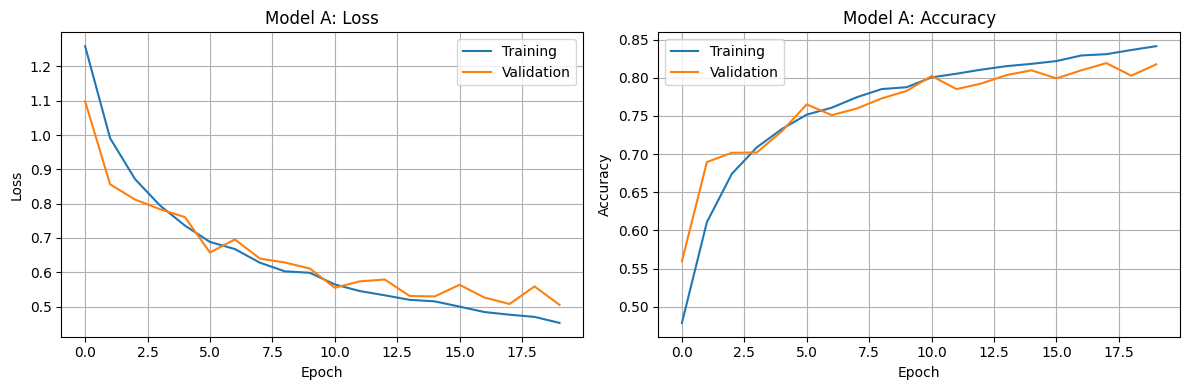

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ["loss", "accuracy"]):
    ax.plot(history.history[metric], label="Training")
    ax.plot(history.history[f"val_{metric}"], label="Validation")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f"Model A: {metric.capitalize()}")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

Model A completed 20 epochs, achieving a final-epoch training accuracy of 84.14% and validation accuracy of 81.76%.

The test set has not yet been evaluated in this experiment. Further hyperparameter tuning will use validation results.

# Model B: Lightweight Depthwise Separable CNN

This model replaces standard convolutions with depthwise separable convolutions. It uses ReLU activations and global average pooling to limit computation and parameter count.

In [15]:
model_b = keras.Sequential([
    keras.Input(shape=(64, 64, 3)),
    keras.layers.Rescaling(1.0 / 255),

    keras.layers.SeparableConv2D(
        32, 3, activation="relu", padding="same"
    ),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.SeparableConv2D(64, 3, activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.SeparableConv2D(128, 3, activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.SeparableConv2D(256, 3, activation="relu"),
    keras.layers.GlobalAveragePooling2D(),

    keras.layers.Dropout(0.4),
    keras.layers.Dense(len(labels), activation="softmax"),
], name="model_b")

model_b.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

trainable_params_b = sum(
    int(np.prod(weight.shape))
    for weight in model_b.trainable_weights
)

print(f"Model B trainable parameters: {trainable_params_b:,}")
assert trainable_params_b <= 100_000, "Model B exceeds the parameter limit!"

model_b.summary()

Model B trainable parameters: 47,169


Model: "model_b"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 64, 64, 32)     │           155 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 30, 30, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 13, 13, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 4, 4, 256)      │        34,176 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,169 (184.25 KB)

 Trainable params: 47,169 (184.25 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_b = model_b.fit(
    train_x,
    train_y,
    epochs=20,
    batch_size=64,
    validation_data=(val_x, val_y),
    verbose=1,
)

Epoch 1/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.2983 - loss: 1.6470 - val_accuracy: 0.4157 - val_loss: 1.3857
Epoch 2/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.4426 - loss: 1.3300 - val_accuracy: 0.4951 - val_loss: 1.2139
Epoch 3/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.5166 - loss: 1.1722 - val_accuracy: 0.5636 - val_loss: 1.0989
Epoch 4/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.5687 - loss: 1.0854 - val_accuracy: 0.5953 - val_loss: 1.0415
Epoch 5/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.5955 - loss: 1.0215 - val_accuracy: 0.6117 - val_loss: 0.9943
Epoch 6/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.6063 - loss: 0.9899 - val_accuracy: 0.6145 - val_loss: 0.9640
Epoch 7/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.6190 - loss: 0.9612 - val_accuracy: 0.6270 - val_loss: 0.9273
Epoch 8/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.6372 - loss: 0.9309 - 

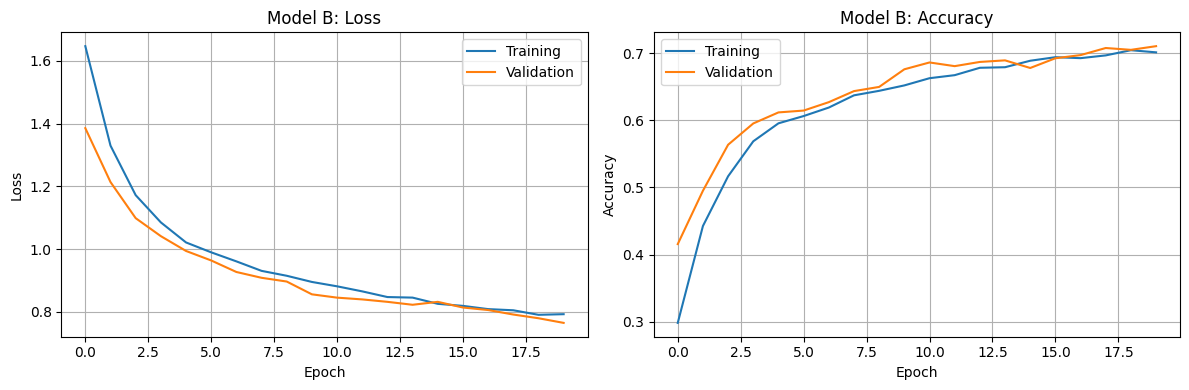

Final training accuracy: 70.12%
Final validation accuracy: 71.04%


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ["loss", "accuracy"]):
    ax.plot(history_b.history[metric], label="Training")
    ax.plot(history_b.history[f"val_{metric}"], label="Validation")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f"Model B: {metric.capitalize()}")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

print(f"Final training accuracy: {history_b.history['accuracy'][-1]:.2%}")
print(f"Final validation accuracy: {history_b.history['val_accuracy'][-1]:.2%}")

## Model B Results and Comparison

After 20 epochs, Model B achieved 70.12% training accuracy and
71.04% validation accuracy. Model A achieved 84.14% training accuracy
and 81.76% validation accuracy under the same training settings.

Model B uses 47,261 trainable parameters compared with Model A's
389,958, a reduction of approximately 88%. Its validation accuracy
was 10.72 percentage points lower in this experiment.

The training and validation curves remain close, while both losses
continue decreasing. This suggests that Model B may benefit from
additional training or different hyperparameters; the curves do not
show clear overfitting in this run.

Validation accuracy being slightly higher than training accuracy is
consistent with dropout being active during training and disabled
during validation.

These results illustrate an accuracy-versus-model-size trade-off.
Computational cost, saved model size, and final test performance
still need to be measured.

## Optimizer Comparison on Model B

Adam, standard SGD, and SGD with momentum are compared using the
same architecture, initial weights, data splits, batch size, and
20-epoch training budget.

Both SGD variants use the same learning rate to examine the effect
of momentum. Model selection uses validation results.

In [25]:
import time
import numpy as np
import pandas as pd

def build_model_b():
    return keras.Sequential([
        keras.Input(shape=(64, 64, 3)),
        keras.layers.Rescaling(1.0 / 255),

        keras.layers.SeparableConv2D(
            32, 3, activation="relu", padding="same"
        ),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.SeparableConv2D(64, 3, activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.SeparableConv2D(128, 3, activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.SeparableConv2D(256, 3, activation="relu"),
        keras.layers.GlobalAveragePooling2D(),

        keras.layers.Dropout(0.4),
        keras.layers.Dense(len(labels), activation="softmax"),
    ], name="model_b")

In [26]:
class EpochTimer(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.seconds = []

    def on_epoch_begin(self, epoch, logs=None):
        self.started_at = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        self.seconds.append(time.perf_counter() - self.started_at)


optimizer_factories = {
    "Adam": lambda: keras.optimizers.Adam(learning_rate=0.0005),
    "SGD": lambda: keras.optimizers.SGD(
        learning_rate=0.01, momentum=0.0
    ),
    "SGD + Momentum": lambda: keras.optimizers.SGD(
        learning_rate=0.01, momentum=0.9
    ),
}

# Reuse identical starting weights across all three experiments.
keras.utils.set_random_seed(42)
initial_model = build_model_b()
initial_weights = initial_model.get_weights()
del initial_model

optimizer_models = {}
optimizer_histories = {}
optimizer_results = []

In [30]:
checkpoint_dir = os.path.join(
    "Best_CNN_models", "optimizer_comparison"
)
os.makedirs(checkpoint_dir, exist_ok=True)

for name, make_optimizer in optimizer_factories.items():
    print(f"\nTraining Model B with {name}")

    keras.utils.set_random_seed(42)
    candidate = build_model_b()
    candidate.set_weights(initial_weights)

    candidate.compile(
        optimizer=make_optimizer(),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    timer = EpochTimer()
    filename = name.lower().replace(" + ", "_").replace(" ", "_")
    checkpoint_path = os.path.join(
        checkpoint_dir, f"model_b_{filename}.keras"
    )

    checkpoint = keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
    )

    run = candidate.fit(
        train_x,
        train_y,
        epochs=20,
        batch_size=64,
        validation_data=(val_x, val_y),
        callbacks=[timer, checkpoint],
        shuffle=True,
        verbose=2,
    )

    values = run.history
    best_index = int(np.argmax(values["val_accuracy"]))

    optimizer_histories[name] = values
    optimizer_models[name] = keras.models.load_model(checkpoint_path)

    optimizer_results.append({
        "Optimizer": name,
        "Learning rate": 0.0005 if name == "Adam" else 0.01,
        "Momentum": (
            np.nan if name == "Adam"
            else 0.9 if name == "SGD + Momentum"
            else 0.0
        ),
        "Best epoch": best_index + 1,
        "Best validation accuracy": values["val_accuracy"][best_index],
        "Validation loss at best epoch": values["val_loss"][best_index],
        "Final training accuracy": values["accuracy"][-1],
        "Final validation accuracy": values["val_accuracy"][-1],
        "Mean seconds per epoch": np.mean(timer.seconds),
    })

print(f"\nCompleted experiments: {len(optimizer_results)}")


Training Model B with Adam
Epoch 1/20
187/187 - 14s - 77ms/step - accuracy: 0.2674 - loss: 1.6816 - val_accuracy: 0.3843 - val_loss: 1.4364
Epoch 2/20
187/187 - 12s - 65ms/step - accuracy: 0.4376 - loss: 1.3680 - val_accuracy: 0.4787 - val_loss: 1.2938
Epoch 3/20
187/187 - 12s - 64ms/step - accuracy: 0.4929 - loss: 1.2338 - val_accuracy: 0.5307 - val_loss: 1.1907
Epoch 4/20
187/187 - 12s - 64ms/step - accuracy: 0.5408 - loss: 1.1393 - val_accuracy: 0.5910 - val_loss: 1.0828
Epoch 5/20
187/187 - 22s - 115ms/step - accuracy: 0.5790 - loss: 1.0692 - val_accuracy: 0.6266 - val_loss: 1.0203
Epoch 6/20
187/187 - 13s - 68ms/step - accuracy: 0.5920 - loss: 1.0335 - val_accuracy: 0.6368 - val_loss: 0.9884
Epoch 7/20
187/187 - 20s - 108ms/step - accuracy: 0.6047 - loss: 1.0018 - val_accuracy: 0.6470 - val_loss: 0.9628
Epoch 8/20
187/187 - 12s - 63ms/step - accuracy: 0.6174 - loss: 0.9809 - val_accuracy: 0.6552 - val_loss: 0.9392
Epoch 9/20
187/187 - 11s - 59ms/step - accuracy: 0.6299 - loss: 0.

In [31]:
optimizer_comparison = pd.DataFrame(optimizer_results).sort_values(
    "Best validation accuracy",
    ascending=False,
).reset_index(drop=True)

display(optimizer_comparison.style.format({
    "Learning rate": "{:.5f}",
    "Momentum": "{:.1f}",
    "Best validation accuracy": "{:.2%}",
    "Validation loss at best epoch": "{:.4f}",
    "Final training accuracy": "{:.2%}",
    "Final validation accuracy": "{:.2%}",
    "Mean seconds per epoch": "{:.2f}",
}, na_rep="-"))

optimizer_comparison.to_csv(
    os.path.join(checkpoint_dir, "optimizer_results.csv"),
    index=False,
)

,Optimizer,Learning rate,Momentum,Best epoch,Best validation accuracy,Validation loss at best epoch,Final training accuracy,Final validation accuracy,Mean seconds per epoch
0,Adam,0.00050,-,20,70.18%,0.7884,69.32%,70.18%,12.87
1,SGD,0.01000,0.0,1,17.81%,1.7910,17.83%,17.81%,10.88
2,SGD + Momentum,0.01000,0.9,1,17.34%,1.7908,17.68%,17.34%,11.08


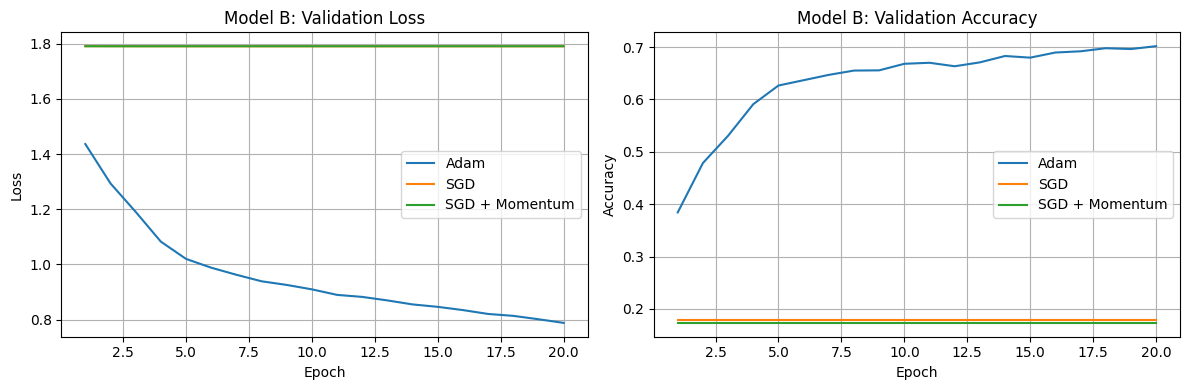

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, values in optimizer_histories.items():
    epochs = range(1, len(values["val_loss"]) + 1)

    axes[0].plot(epochs, values["val_loss"], label=name)
    axes[1].plot(epochs, values["val_accuracy"], label=name)

axes[0].set_title("Model B: Validation Loss")
axes[0].set_ylabel("Loss")

axes[1].set_title("Model B: Validation Accuracy")
axes[1].set_ylabel("Accuracy")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [33]:
selected_optimizer_b = optimizer_comparison.iloc[0]["Optimizer"]
selected_model_b = optimizer_models[selected_optimizer_b]

print(f"Selected optimizer: {selected_optimizer_b}")
print(
    "Best validation accuracy: "
    f"{optimizer_comparison.iloc[0]['Best validation accuracy']:.2%}"
)

Selected optimizer: Adam
Best validation accuracy: 70.18%


In [34]:
# Additional SGD learning-rate experiments.
# Existing optimizer_results, models, and histories are preserved.
extra_optimizer_factories = {
    "SGD lr=0.001": lambda: keras.optimizers.SGD(
        learning_rate=0.001, momentum=0.0
    ),
    "SGD lr=0.1": lambda: keras.optimizers.SGD(
        learning_rate=0.1, momentum=0.0
    ),
    "Momentum lr=0.001": lambda: keras.optimizers.SGD(
        learning_rate=0.001, momentum=0.9
    ),
    "Momentum lr=0.1": lambda: keras.optimizers.SGD(
        learning_rate=0.1, momentum=0.9
    ),
}

extra_checkpoint_dir = os.path.join(
    "Best_CNN_models", "sgd_learning_rate_comparison"
)
os.makedirs(extra_checkpoint_dir, exist_ok=True)

for name, make_optimizer in extra_optimizer_factories.items():
    print(f"\nTraining Model B with {name}")

    keras.utils.set_random_seed(42)
    candidate = build_model_b()
    candidate.set_weights(initial_weights)

    candidate.compile(
        optimizer=make_optimizer(),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    timer = EpochTimer()
    filename = name.lower().replace(" ", "_").replace("=", "_")
    checkpoint_path = os.path.join(
        extra_checkpoint_dir, f"model_b_{filename}.keras"
    )

    checkpoint = keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
    )

    run = candidate.fit(
        train_x,
        train_y,
        epochs=20,
        batch_size=64,
        validation_data=(val_x, val_y),
        callbacks=[timer, checkpoint],
        shuffle=True,
        verbose=2,
    )

    values = run.history
    best_index = int(np.argmax(values["val_accuracy"]))

    optimizer_histories[name] = values
    optimizer_models[name] = keras.models.load_model(checkpoint_path)

    # Replace this experiment's previous row if this cell is rerun.
    optimizer_results[:] = [
        row for row in optimizer_results
        if row["Optimizer"] != name
    ]

    optimizer_results.append({
        "Optimizer": name,
        "Learning rate": float(
            keras.backend.get_value(candidate.optimizer.learning_rate)
        ),
        "Momentum": float(candidate.optimizer.momentum),
        "Best epoch": best_index + 1,
        "Best validation accuracy": values["val_accuracy"][best_index],
        "Validation loss at best epoch": values["val_loss"][best_index],
        "Final training accuracy": values["accuracy"][-1],
        "Final validation accuracy": values["val_accuracy"][-1],
        "Mean seconds per epoch": np.mean(timer.seconds),
    })

optimizer_comparison = pd.DataFrame(optimizer_results).sort_values(
    "Best validation accuracy", ascending=False
).reset_index(drop=True)

display(optimizer_comparison)

optimizer_comparison.to_csv(
    os.path.join(extra_checkpoint_dir, "combined_optimizer_results.csv"),
    index=False,
)


Training Model B with SGD lr=0.001
Epoch 1/20
187/187 - 13s - 68ms/step - accuracy: 0.1800 - loss: 1.7917 - val_accuracy: 0.1789 - val_loss: 1.7916
Epoch 2/20
187/187 - 11s - 61ms/step - accuracy: 0.1802 - loss: 1.7916 - val_accuracy: 0.1781 - val_loss: 1.7915
Epoch 3/20
187/187 - 11s - 60ms/step - accuracy: 0.1784 - loss: 1.7915 - val_accuracy: 0.1781 - val_loss: 1.7914
Epoch 4/20
187/187 - 11s - 60ms/step - accuracy: 0.1783 - loss: 1.7914 - val_accuracy: 0.1781 - val_loss: 1.7913
Epoch 5/20
187/187 - 12s - 62ms/step - accuracy: 0.1783 - loss: 1.7913 - val_accuracy: 0.1781 - val_loss: 1.7913
Epoch 6/20
187/187 - 11s - 60ms/step - accuracy: 0.1783 - loss: 1.7912 - val_accuracy: 0.1781 - val_loss: 1.7912
Epoch 7/20
187/187 - 11s - 59ms/step - accuracy: 0.1783 - loss: 1.7912 - val_accuracy: 0.1781 - val_loss: 1.7911
Epoch 8/20
187/187 - 11s - 57ms/step - accuracy: 0.1783 - loss: 1.7911 - val_accuracy: 0.1781 - val_loss: 1.7911
Epoch 9/20
187/187 - 11s - 57ms/step - accuracy: 0.1783 - lo

,Optimizer,Learning rate,Momentum,Best epoch,Best validation accuracy,Validation loss at best epoch,Final training accuracy,Final validation accuracy,Mean seconds per epoch
0,Adam,0.0005,NaN,20,0.701761,0.788423,0.693198,0.701761,12.874321
1,SGD lr=0.001,0.0010,0.0,1,0.178865,1.791613,0.178311,0.178082,11.064288
2,SGD,0.0100,0.0,1,0.178082,1.791038,0.178311,0.178082,10.878416
3,Momentum lr=0.001,0.0010,0.9,1,0.178082,1.791002,0.178311,0.178082,11.671577
4,SGD + Momentum,0.0100,0.9,1,0.173386,1.790840,0.176801,0.173386,11.081857
5,SGD lr=0.1,0.1000,0.0,1,0.173386,1.790792,0.175543,0.173386,11.136329
6,Momentum lr=0.1,0.1000,0.9,1,0.154599,1.797702,0.172356,0.154599,11.385104


In [35]:
for name in ["SGD lr=0.001", "SGD lr=0.1"]:
    if name not in optimizer_models:
        print(f"{name}: run has not finished yet")
        continue

    probabilities = optimizer_models[name].predict(
        val_x, batch_size=64, verbose=0
    )
    predictions = probabilities.argmax(axis=1)

    print(f"\n{name}")
    print("Predicted class counts:", dict(zip(
        labels,
        np.bincount(predictions, minlength=len(labels)),
    )))
    print("Probability variation:", probabilities.std(axis=0))


SGD lr=0.001
Predicted class counts: {'buildings': 0, 'forest': 0, 'glacier': 21, 'mountain': 2534, 'sea': 0, 'street': 0}
Probability variation: [1.7367323e-05 1.0940057e-05 3.1073821e-05 1.4141955e-05 1.2943557e-05
 8.7293975e-06]

SGD lr=0.1
Predicted class counts: {'buildings': 0, 'forest': 0, 'glacier': 2555, 'mountain': 0, 'sea': 0, 'street': 0}
Probability variation: [9.4134120e-06 3.7103234e-06 1.1424230e-05 1.3639299e-05 5.5445871e-06
 8.3774039e-06]


## Hyperparameter tuning

In [ ]:
def build_model(hp):
    model = keras.Sequential()

    hp_learn_rate = hp.Float("learning_rate", min_value=1e-5, max_value=1e-2,sampling='log')
    hp_drop_rate = hp.Float("drop_rate", min_value=0, max_value=1, step=0.1)

    model.add(keras.Input(shape=(64, 64, 3)))
    model.add(keras.layers.Conv2D(32, 3, activation="relu", padding="same"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(64, 3, activation="relu"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(128, 3, activation="relu"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(256, 3, activation="relu"))
    model.add(keras.layers.GlobalAveragePooling2D())

    model.add(keras.layers.Dropout(hp_drop_rate))
    model.add(keras.layers.Dense(len(labels),"softmax"))

    metrics = hp.Choice("metrics", values=["accuracy", "categorical_accuracy"])

    optimizer = keras.optimizers.Adam(learning_rate=hp_learn_rate)

    model.compile(optimizer, loss="sparse_categorical_crossentropy", metrics=[metrics])
    
    return model

In [4]:
tuner = kt.GridSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    directory="CNN_search",
    project_name="Model_selection2",
    overwrite=False,
)

reseed_grid_picker(tuner)  # Workaround from the previous answer

x_train, x_val, y_train, y_val = train_test_split(train_x, train_y, test_size=0.1, random_state=42, shuffle=False)

tuner.search(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_val, y_val),
)

Reloading Tuner from CNN_search/Model_selection2/tuner0.json


I0000 00:00:1790141765.226628  875123 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Choosing the top 10 models for further tuning

In [5]:
best_params = tuner.get_best_hyperparameters(10)
best_models = tuner.get_best_models(10)

/home/nilesh/miniconda3/envs/tf220/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(store)


In [ ]:
params_df = []
for i, param in enumerate(best_params):
    loss, accuracy = best_models[i].evaluate(test_x, test_y, verbose=0)

    params_df.append({"name": f"model{i}",
                      "model": best_models[i] ,
                      "param": param,
                      "loss": loss,
                      "accuracy": accuracy,
                      "learning_rate": param["learning_rate"],
                      "drop_rate" : param["drop_rate"],
                      "metric": param["metrics"]})

params_df = pd.DataFrame(params_df).sort_values("accuracy", ascending=False, ignore_index=True)

params_df

,name,model,param,loss,accuracy,learning_rate,drop_rate,metric
0,model5,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.524637,0.810333,0.000447,0.1,accuracy
1,model0,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.568092,0.808667,0.000447,0.6,accuracy
2,model7,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.554908,0.806333,0.000447,0.4,accuracy
3,model1,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.561818,0.806000,0.000891,0.4,accuracy
4,model2,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.583540,0.804333,0.000891,0.0,accuracy
5,model8,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.586864,0.802667,0.000224,0.0,accuracy
6,model9,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.577724,0.801000,0.000447,0.3,accuracy
7,model3,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.581876,0.794000,0.000447,0.7,accuracy
8,model4,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.589521,0.791667,0.000891,0.5,accuracy
9,model6,"<Sequential name=sequential, built=True>",<keras_tuner.src.engine.hyperparameters.hyperp...,0.604857,0.787333,0.000891,0.7,accuracy


Top 6 models are chosen to fine tune

In [76]:
models = []
histories = []
top = 6
progress = tqdm(None, "Model", top, initial=0)
for i, params in params_df.iterrows():
    models.append(build_model(params["param"]))
    histories.append(models[-1].fit(train_x, train_y, epochs=15, validation_split=0.1, batch_size=64,verbose=0))
    if i >= top:
        break
    progress.update()

Model: 100%|██████████| 6/6 [02:44<00:00, 27.20s/it]

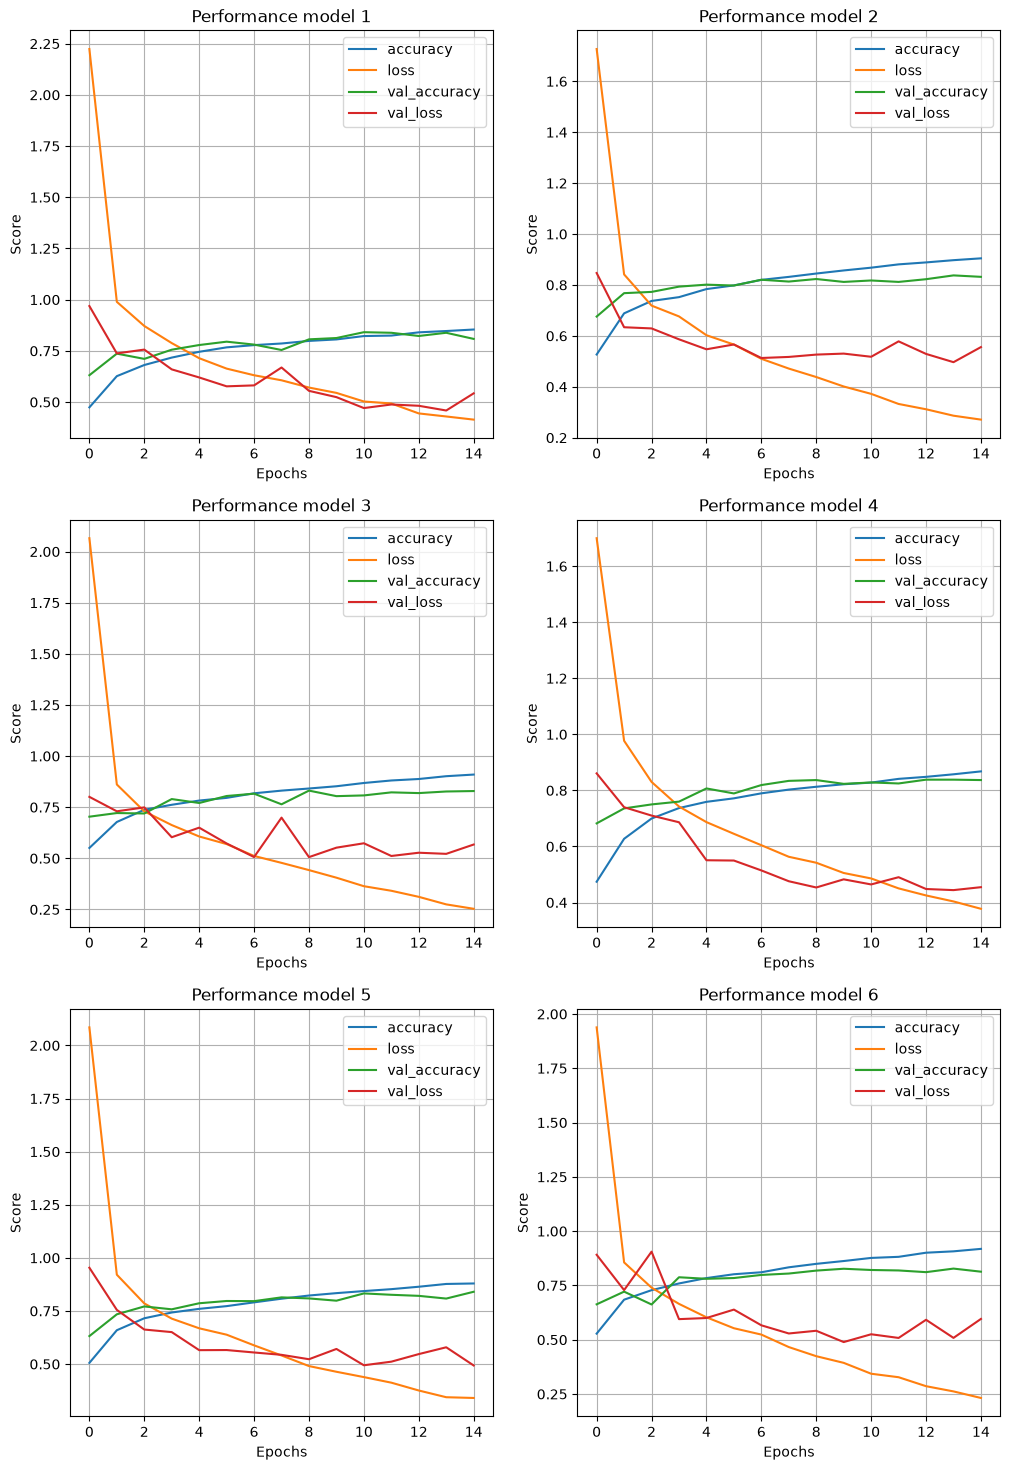

In [17]:
plt.figure(figsize=(12,18))
for i, history in enumerate(histories):
    plt.subplot(3,2,i+1)
    for key in history.history.keys():
        plt.plot(history.history[key], label=key)
    plt.xlabel("Epochs")
    plt.ylabel("Score")
    plt.title(f"Performance model {i+1}")
    plt.grid()
    plt.legend()

plt.show()

In [21]:
for i, model in enumerate(best_models[:top]):
    model.save(os.path.join(os.curdir, "CNN_models", "best_models", f"model{i}.keras"), overwrite=True)

# With Dense layers

In [3]:
def build_model(hp):
    model = keras.Sequential()
    hp_drop_rate = hp.Choice("drop_rate", values=[0.0, 0.4, 0.7, 0.1, 0.6])

    model.add(keras.Input(shape=(64, 64, 3)))
    model.add(keras.layers.Conv2D(32, 3, activation="relu", padding="same"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(64, 3, activation="relu"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(128, 3, activation="relu"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(256, 3, activation="relu"))
    model.add(keras.layers.GlobalAveragePooling2D())

    hp_layers = hp.Int("layer", min_value=0, max_value=3, step=1)
    units = {}
    dropouts = {}

    for i in range(1, 4):
        with hp.conditional_scope("layer", list(range(i, 4))):
            units[i] = hp.Choice(
                f"unit{i}",
                values=[32, 64, 128, 256, 512],
            )
            dropouts[i] = hp.Float(
                f"drop{i}",
                min_value=0.1,
                max_value=0.9,
                step=0.1,
            )

    for i in range(hp_layers, 0, -1):
        model.add(keras.layers.Dense(units[i], activation="relu"))
        model.add(keras.layers.Dropout(dropouts[i]))

    model.add(keras.layers.Dropout(hp_drop_rate))

    model.add(keras.layers.Dense(len(labels),"softmax"))

    optimizer = keras.optimizers.Adam(learning_rate=0.000447)

    model.compile(optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    return model

In [ ]:
tuner = kt.GridSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    directory="CNN_search",
    project_name="Model_selection3",
    overwrite=False,
)

reseed_grid_picker(tuner)  # Workaround from the previous answer

x_train, x_val, y_train, y_val = train_test_split(train_x, train_y, test_size=0.1, random_state=42, shuffle=False)

tuner.search(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_val, y_val),
)

Trial 1521 Complete [00h 00m 17s]
val_accuracy: 0.7827635407447815

Best val_accuracy So Far: 0.8311966061592102
Total elapsed time: 2d 03h 55m 16s

Search: Running Trial #1522

Value             |Best Value So Far |Hyperparameter
0                 |0                 |drop_rate
2                 |2                 |layer
0.6               |0.4               |drop1
256               |256               |unit1
0.9               |0.2               |drop2
256               |512               |unit2

Epoch 1/5
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2653 - loss: 2.0468

# With BatchNormalize

In [ ]:
def build_model(hp):
    model = keras.Sequential()

    hp_learn_rate = hp.Float("learning_rate", min_value=1e-5, max_value=1e-2,sampling='log')
    hp_drop_rate = hp.Float("drop_rate", min_value=0, max_value=1, step=0.1)

    

    model.add(keras.Input(shape=(64, 64, 3)))
    model.add(keras.layers.Conv2D(32, 3, activation="relu", padding="same"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(64, 3, activation="relu"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(128, 3, activation="relu"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(256, 3, activation="relu"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.GlobalAveragePooling2D())

    model.add(keras.layers.Dropout(hp_drop_rate))
    model.add(keras.layers.Dense(len(labels),"softmax"))

    optimizer = keras.optimizers.Adam(learning_rate=hp_learn_rate)

    model.compile(optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    return model

In [ ]:
tuner = kt.GridSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    directory="CNN_search",
    project_name="Model_selection4",
    overwrite=False,
)

reseed_grid_picker(tuner)  # Workaround from the previous answer

x_train, x_val, y_train, y_val = train_test_split(train_x, train_y, test_size=0.1, random_state=42, shuffle=False)

tuner.search(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_val, y_val),
)

In [ ]:
best_params = tuner.get_best_hyperparameters(10)
best_models = tuner.get_best_models(10)

In [ ]:
params_df = []
for i, param in enumerate(best_params):
    loss, accuracy = best_models[i].evaluate(test_x, test_y, verbose=0)

    params_df.append({"name": f"model{i}",
                      "model": best_models[i] ,
                      "param": param,
                      "loss": loss,
                      "accuracy": accuracy,
                      "learning_rate": param["learning_rate"],
                      "drop_rate" : param["drop_rate"]})

params_df = pd.DataFrame(params_df).sort_values("accuracy", ascending=False, ignore_index=True)

params_df

In [ ]:
models = []
histories = []
top = 6
progress = tqdm(None, "Model", top, initial=0)
for i, params in params_df.iterrows():
    models.append(build_model(params["param"]))
    histories.append(models[-1].fit(train_x, train_y, epochs=15, validation_split=0.1, batch_size=64,verbose=0))
    if i >= top:
        break
    progress.update()

In [ ]:
plt.figure(figsize=(12,18))
for i, history in enumerate(histories):
    plt.subplot(3,2,i+1)
    for key in history.history.keys():
        plt.plot(history.history[key], label=key)
    plt.xlabel("Epochs")
    plt.ylabel("Score")
    plt.title(f"Performance model {i+1}")
    plt.grid()
    plt.legend()

plt.show()

In [ ]:
for i, model in enumerate(best_models[:top]):
    model.save(os.path.join(os.curdir, "Best_CNN_models", "CNN_BatchNormalize", f"model{i}.keras"), overwrite=True)

In [ ]:
from tensorflow.keras.callbacks import Callback


# Fine tuning

## Base CNN

In [3]:
cnn_params = pd.read_csv(os.path.join(os.path.curdir, "Best_CNN_models", "CNN", "params.csv"))
cnn_configs = {}
for index, params in cnn_params[:5].iterrows():
    cnn_configs[f"config{index}"] = {"lr" : params["learning_rate"],
                                     "drop_rate" : params["drop_rate"]}

cnn_configs

{'config0': {'lr': 0.0004466835921509, 'drop_rate': 0.1},
 'config1': {'lr': 0.0004466835921509, 'drop_rate': 0.6000000000000001},
 'config2': {'lr': 0.0004466835921509, 'drop_rate': 0.4},
 'config3': {'lr': 0.0008912509381337, 'drop_rate': 0.4},
 'config4': {'lr': 0.0008912509381337, 'drop_rate': 0.0}}

In [4]:
def build_CNN_fine(hp):

    config_name = hp.Choice("base_config", list(cnn_configs.keys()))

    config = cnn_configs[config_name]

    rotation = hp.Choice("rotation",[0.0, 0.03, 0.05, 0.08])

    zoom = hp.Choice("zoom",[0.0, 0.05, 0.1, 0.15])

    contrast = hp.Choice("contrast",[0.0, 0.05, 0.1, 0.15])

    translation = hp.Choice("translation",[0.0, 0.05, 0.1])

    augmentation = keras.Sequential([
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(rotation),
        keras.layers.RandomZoom(zoom),
        keras.layers.RandomContrast(contrast),
        keras.layers.RandomTranslation(translation,translation)
    ])

    model = keras.Sequential()

    model.add(keras.Input(shape=(64, 64, 3)))
    model.add(augmentation)
    model.add(keras.layers.Conv2D(32, 3, activation="relu", padding="same"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(64, 3, activation="relu"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(128, 3, activation="relu"))
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(256, 3, activation="relu"))
    model.add(keras.layers.GlobalAveragePooling2D())

    model.add(keras.layers.Dropout(config["drop_rate"]))
    model.add(keras.layers.Dense(len(labels),"softmax"))


    optimizer = keras.optimizers.Adam(learning_rate=config["lr"])

    model.compile(optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    return model

In [5]:
CNN_tuner = kt.GridSearch(
    hypermodel=build_CNN_fine,
    objective="val_accuracy",
    directory="CNN_search_fine",
    project_name="cnn",
    overwrite=False,
)

I0000 00:00:1790590998.568765  151632 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Reloading Tuner from CNN_search_fine/cnn/tuner0.json


In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

x_train, x_val, y_train, y_val = train_test_split(train_x, train_y, test_size=0.1, random_state=42, shuffle=False)
reseed_grid_picker(CNN_tuner) 
CNN_tuner.search(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=5,
    callbacks=callbacks
)

## Batch Normalize

In [7]:
batch_params = pd.read_csv(os.path.join(os.path.curdir, "Best_CNN_models", "CNN_BatchNormalize", "params.csv"))
batch_configs = {}
for index, params in batch_params[:5].iterrows():
    batch_configs[f"config{index}"] = {"lr" : params["learning_rate"],
                                     "drop_rate" : params["drop_rate"]}

batch_configs

{'config0': {'lr': 0.0017782794100389, 'drop_rate': 0.5},
 'config1': {'lr': 0.0001122018454301, 'drop_rate': 0.1},
 'config2': {'lr': 0.0001122018454301, 'drop_rate': 0.4},
 'config3': {'lr': 0.0002238721138568, 'drop_rate': 0.1},
 'config4': {'lr': 0.0002238721138568, 'drop_rate': 0.5}}

In [8]:
def build_batch_fine(hp):
    config_name = hp.Choice("base_config", list(batch_configs.keys()))

    config = batch_configs[config_name]

    rotation = hp.Choice("rotation",[0.0, 0.03, 0.05, 0.08])

    zoom = hp.Choice("zoom",[0.0, 0.05, 0.1, 0.15])

    contrast = hp.Choice("contrast",[0.0, 0.05, 0.1, 0.15])

    translation = hp.Choice("translation",[0.0, 0.05, 0.1])

    augmentation = keras.Sequential([
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(rotation),
        keras.layers.RandomZoom(zoom),
        keras.layers.RandomContrast(contrast),
        keras.layers.RandomTranslation(translation,translation)
    ])
    model = keras.Sequential()
    model.add(keras.Input(shape=(64, 64, 3)))
    model.add(augmentation)
    model.add(keras.layers.Conv2D(32, 3, activation="relu", padding="same"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(64, 3, activation="relu"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(128, 3, activation="relu"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.MaxPooling2D((2,2)))
    model.add(keras.layers.Conv2D(256, 3, activation="relu"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.GlobalAveragePooling2D())

    model.add(keras.layers.Dropout(config["drop_rate"]))
    model.add(keras.layers.Dense(len(labels),"softmax"))

    optimizer = keras.optimizers.Adam(learning_rate=config["lr"])

    model.compile(optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    return model

In [9]:
batch_tuner = kt.GridSearch(
    hypermodel=build_batch_fine,
    objective="val_accuracy",
    directory="CNN_search_fine",
    project_name="batch",
    overwrite=False,
)

Reloading Tuner from CNN_search_fine/batch/tuner0.json


In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

x_train, x_val, y_train, y_val = train_test_split(train_x, train_y, test_size=0.1, random_state=42, shuffle=False)
reseed_grid_picker(batch_tuner) 
batch_tuner.search(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=5,
    callbacks=callbacks
)

## Evaluation of the 2 models

In [11]:
combined_params = []
params = [CNN_tuner.get_best_hyperparameters(10),batch_tuner.get_best_hyperparameters(10)]
best_models = [CNN_tuner.get_best_models(10), batch_tuner.get_best_models(10)]
for i, archi in enumerate(params):
    if i == 0:
        configs = cnn_configs
    else:
        configs = batch_configs
    for j, param in enumerate(archi):
        loss, accuracy = best_models[i][j].evaluate(test_x, test_y, verbose=0)
        base = param["base_config"]
        combined_params.append({"name": f"model_{i}_{j}",
                                "model": best_models[i][j],
                                "architecture" : i,
                                "param": param,
                                "loss": loss,
                                "accuracy": accuracy,
                                "config" : param["base_config"],
                                "learning_rate": configs[base]["lr"],
                                "drop_rate" : configs[base]["drop_rate"],
                                "rotation": param["rotation"],
                                "zoom": param["zoom"],
                                "contrast": param["contrast"],
                                "translation": param["translation"],
                                })

combined_params = pd.DataFrame(combined_params).sort_values("accuracy", ascending=False, ignore_index=True)

combined_params

/home/nilesh/miniconda3/envs/tf220/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(store)
/home/nilesh/miniconda3/envs/tf220/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(store)
2026-09-28 15:53:29.304570: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92600


,name,model,architecture,param,loss,accuracy,config,learning_rate,drop_rate,rotation,zoom,contrast,translation
0,model_1_0,"<Sequential name=sequential_1, built=True>",1,<keras_tuner.src.engine.hyperparameters.hyperp...,0.462512,0.844000,config0,0.001778,0.5,0.0,0.05,0.10,0.00
1,model_1_5,"<Sequential name=sequential_1, built=True>",1,<keras_tuner.src.engine.hyperparameters.hyperp...,0.464251,0.837667,config3,0.000224,0.1,0.0,0.05,0.05,0.00
2,model_1_7,"<Sequential name=sequential_1, built=True>",1,<keras_tuner.src.engine.hyperparameters.hyperp...,0.495284,0.829667,config4,0.000224,0.5,0.0,0.10,0.15,0.00
3,model_1_8,"<Sequential name=sequential_1, built=True>",1,<keras_tuner.src.engine.hyperparameters.hyperp...,0.509797,0.827333,config3,0.000224,0.1,0.0,0.00,0.15,0.00
4,model_1_2,"<Sequential name=sequential_1, built=True>",1,<keras_tuner.src.engine.hyperparameters.hyperp...,0.506851,0.824000,config3,0.000224,0.1,0.0,0.15,0.15,0.00
5,model_1_1,"<Sequential name=sequential_1, built=True>",1,<keras_tuner.src.engine.hyperparameters.hyperp...,0.517991,0.821333,config1,0.000112,0.1,0.0,0.05,0.15,0.00
6,model_1_6,"<Sequential name=sequential_1, built=True>",1,<keras_tuner.src.engine.hyperparameters.hyperp...,0.511113,0.819333,config1,0.000112,0.1,0.0,0.00,0.15,0.10
7,model_1_9,"<Sequential name=sequential_1, built=True>",1,<keras_tuner.src.engine.hyperparameters.hyperp...,0.516615,0.815667,config3,0.000224,0.1,0.0,0.15,0.05,0.00
8,model_0_4,"<Sequential name=sequential_1, built=True>",0,<keras_tuner.src.engine.hyperparameters.hyperp...,0.538727,0.815333,config2,0.000447,0.4,0.0,0.00,0.00,0.00
9,model_1_3,"<Sequential name=sequential_1, built=True>",1,<keras_tuner.src.engine.hyperparameters.hyperp...,0.529258,0.814333,config4,0.000224,0.5,0.0,0.00,0.10,0.05


In [14]:
class TQDMProgressBar(Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self.bar = tqdm(total=self.params['steps'], desc=f"Epoch {epoch+1}/{self.params['epochs']}")

    def on_train_batch_end(self, batch, logs=None):
        self.bar.update(1)

    def on_epoch_end(self, epoch, logs=None):
        self.bar.close()

class EpochProgressBar(Callback):
    def on_train_begin(self, logs=None):
        self.epochs_bar = tqdm(
            total=self.params['epochs'],
            desc="Training Progress",
            unit="epoch"
        )

    def on_epoch_end(self, epoch, logs=None):
        self.epochs_bar.update(1)
        self.epochs_bar.set_postfix(
            loss=f"{logs['loss']:.4f}",
            acc=f"{logs.get('accuracy', 0):.4f}",
            val_loss=f"{logs.get('val_loss', 0):.4f}",
            val_acc=f"{logs.get('val_accuracy', 0):.4f}"
        )

    def on_train_end(self, logs=None):
        self.epochs_bar.close()

In [15]:
histories = []
val_loss = []
val_acc = []
progress = tqdm(desc="model", total=len(combined_params), unit="model")
for i, settings in combined_params.iterrows():
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            "fine_tune_best/best_model.keras",
            monitor="val_accuracy",
            mode="max",
            save_best_only=True
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6
        ),

        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            min_delta=1e-3,
            restore_best_weights=True
        ),
        EpochProgressBar()
    ]
    params={"rotation":settings["rotation"],
            "zoom":settings["zoom"],
            "contrast":settings["contrast"],
            "translation":settings["translation"],
            "base_config":settings["config"]
            }
    hp = kt.HyperParameters()
    hp.values = params
    if settings["architecture"] == 0:
        model = build_CNN_fine(hp)
    else:
        model = build_batch_fine(hp)

    history = model.fit(train_x, train_y, validation_split=0.1, epochs=15, batch_size=32, shuffle=True, callbacks=callbacks, verbose=0)
    histories.append(history)
    
    combined_params.at[i, "model"] = model

    loss, acc = model.evaluate( x_val, y_val)
    val_acc.append(acc)
    val_loss.append(loss)
    progress.update()

combined_params["history"] = histories
combined_params["val_acc"] = val_acc
combined_params["val_loss"] = val_loss

Training Progress: 100%|██████████| 15/15 [01:04<00:00,  4.32s/epoch, acc=0.8983, loss=0.2772, val_acc=0.8832, val_loss=0.3456]

17/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9062 - loss: 0.3217 

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8981 - loss: 0.3302


Training Progress: 100%|██████████| 15/15 [01:05<00:00,  4.40s/epoch, acc=0.9124, loss=0.2629, val_acc=0.8547, val_loss=0.4220]

18/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8559 - loss: 0.4156 

...

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8618 - loss: 0.4049


Training Progress: 100%|██████████| 15/15 [00:40<00:00,  2.68s/epoch, acc=0.8783, loss=0.3363, val_acc=0.8533, val_loss=0.4487]

18/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8507 - loss: 0.4513 

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8533 - loss: 0.4487


model: 100%|██████████| 20/20 [17:58<00:00, 42.54s/model]

In [16]:
combined_params = pd.DataFrame(combined_params).sort_values("val_acc", ascending=False, ignore_index=True)
combined_params.head(10)

,name,model,architecture,param,loss,accuracy,config,learning_rate,drop_rate,rotation,zoom,contrast,translation,history,val_acc,val_loss
0,model_1_0,"<Sequential name=sequential_5, built=True>",1,<keras_tuner.src.engine.hyperparameters.hyperp...,0.462512,0.844000,config0,0.001778,0.5,0.0,0.05,0.10,0.00,<keras.src.callbacks.history.History object at...,0.898148,0.330171
1,model_1_9,"<Sequential name=sequential_19, built=True>",1,<keras_tuner.src.engine.hyperparameters.hyperp...,0.516615,0.815667,config3,0.000224,0.1,0.0,0.15,0.05,0.00,<keras.src.callbacks.history.History object at...,0.877493,0.353751
2,model_1_1,"<Sequential name=sequential_15, built=True>",1,<keras_tuner.src.engine.hyperparameters.hyperp...,0.517991,0.821333,config1,0.000112,0.1,0.0,0.05,0.15,0.00,<keras.src.callbacks.history.History object at...,0.872507,0.370543
3,model_1_3,"<Sequential name=sequential_23, built=True>",1,<keras_tuner.src.engine.hyperparameters.hyperp...,0.529258,0.814333,config4,0.000224,0.5,0.0,0.00,0.10,0.05,<keras.src.callbacks.history.History object at...,0.872507,0.374056
4,model_1_8,"<Sequential name=sequential_11, built=True>",1,<keras_tuner.src.engine.hyperparameters.hyperp...,0.509797,0.827333,config3,0.000224,0.1,0.0,0.00,0.15,0.00,<keras.src.callbacks.history.History object at...,0.869658,0.367408
5,model_1_5,"<Sequential name=sequential_7, built=True>",1,<keras_tuner.src.engine.hyperparameters.hyperp...,0.464251,0.837667,config3,0.000224,0.1,0.0,0.05,0.05,0.00,<keras.src.callbacks.history.History object at...,0.863248,0.402934
6,model_1_7,"<Sequential name=sequential_9, built=True>",1,<keras_tuner.src.engine.hyperparameters.hyperp...,0.495284,0.829667,config4,0.000224,0.5,0.0,0.10,0.15,0.00,<keras.src.callbacks.history.History object at...,0.861823,0.389129
7,model_0_3,"<Sequential name=sequential_41, built=True>",0,<keras_tuner.src.engine.hyperparameters.hyperp...,0.573167,0.794333,config2,0.000447,0.4,0.0,0.00,0.05,0.00,<keras.src.callbacks.history.History object at...,0.861823,0.404864
8,model_0_1,"<Sequential name=sequential_37, built=True>",0,<keras_tuner.src.engine.hyperparameters.hyperp...,0.554619,0.808000,config2,0.000447,0.4,0.0,0.00,0.10,0.00,<keras.src.callbacks.history.History object at...,0.860399,0.415006
9,model_0_4,"<Sequential name=sequential_21, built=True>",0,<keras_tuner.src.engine.hyperparameters.hyperp...,0.538727,0.815333,config2,0.000447,0.4,0.0,0.00,0.00,0.00,<keras.src.callbacks.history.History object at...,0.859687,0.412353


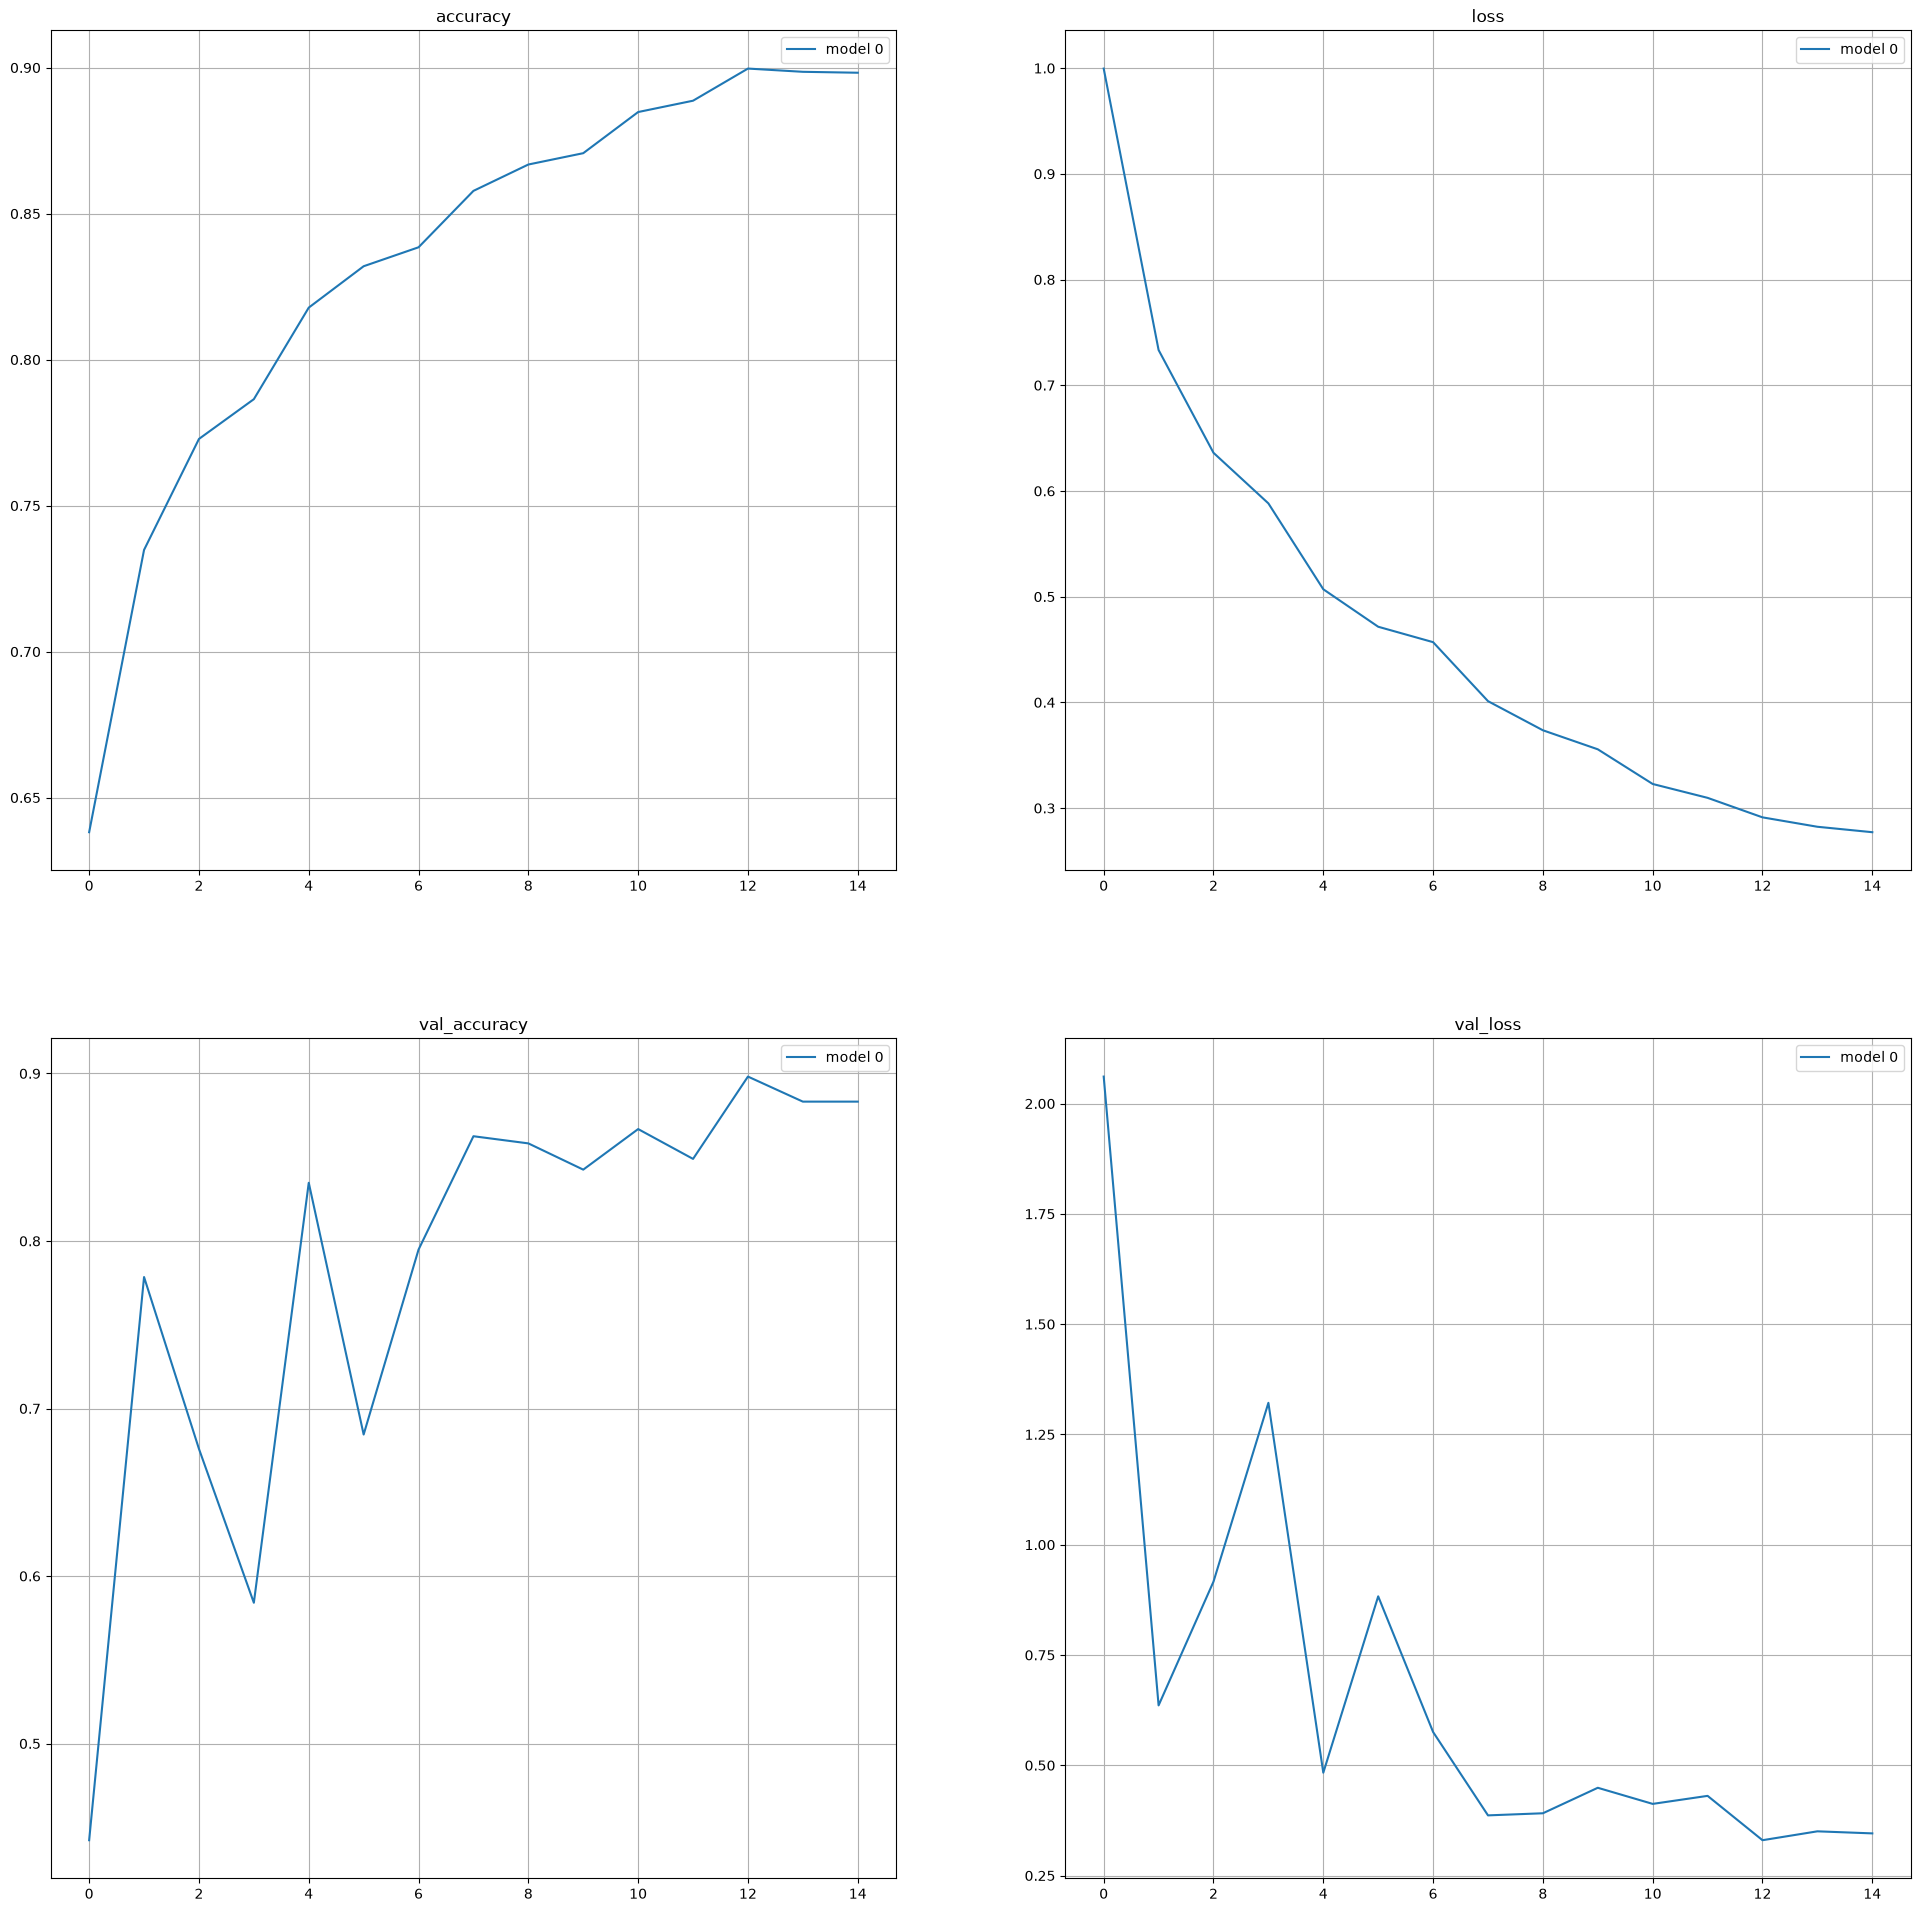

In [19]:
fig, ax = plt.subplots(2, 2, figsize=(24, 24))
for i, metric in enumerate(["accuracy", "loss", "val_accuracy", "val_loss"]):
    axis = ax[i//2][i%2]
    for j, settings in combined_params[:1].iterrows():
        # print(settings["history"].history.keys())
        # break
        axis.plot(settings["history"].epoch, settings["history"].history[metric], label=f"model {j}")
        axis.set_title(metric)
        axis.grid(True)
        axis.legend()

plt.show()

In [20]:
tune_params = combined_params.head(10)

In [24]:
class TQDMProgressBar(keras.callbacks.Callback):
    def __init__(self, total_epochs, position=1):
        super().__init__()
        self.total_epochs = total_epochs
        self.position = position
        self.pbar = None

    def on_train_begin(self, logs=None):
        self.pbar = tqdm(
            total=self.total_epochs,
            desc="Training",
            position=self.position,
            leave=False,
            unit="epoch"
        )

    def on_epoch_end(self, epoch, logs=None):
        self.pbar.update(1)

        if logs:
            loss = logs.get("loss", 0)
            acc = logs.get("accuracy", 0)
            val_loss = logs.get("val_loss", 0)
            val_acc = logs.get("val_accuracy", 0)

            self.pbar.set_postfix(
                loss=f"{loss:.3f}",
                acc=f"{acc:.3f}",
                val_loss=f"{val_loss:.3f}",
                val_acc=f"{val_acc:.3f}"
            )

    def on_train_end(self, logs=None):
        self.pbar.close()

In [27]:
histories = []
val_loss = []
val_acc = []

progress = tqdm(
    desc="Models",
    total=len(tune_params),
    unit="config"
)

for idx, settings in tune_params.iterrows():

    callbacks_base = [
        keras.callbacks.ModelCheckpoint(
            "fine_tune_best/best_model.keras",
            monitor="val_accuracy",
            mode="max",
            save_best_only=True
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6
        ),

        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            min_delta=1e-3,
            restore_best_weights=True
        )
    ]

    params = {
        "rotation": settings["rotation"],
        "zoom": settings["zoom"],
        "contrast": settings["contrast"],
        "translation": settings["translation"],
        "base_config": settings["config"]
    }

    hp = kt.HyperParameters()
    hp.values = params

    history = []
    models = []
    evaluations = []

    for model_id in range(3):

        callbacks = callbacks_base + [
            TQDMProgressBar(
                total_epochs=15,
                position=1
            )
        ]

        if settings["architecture"] == 0:
            net = build_CNN_fine(hp)
        else:
            net = build_batch_fine(hp)

        hist = net.fit(
            train_x,
            train_y,
            validation_split=0.1,
            epochs=15,
            batch_size=32,
            shuffle=True,
            callbacks=callbacks,
            verbose=0
        )

        history.append(hist)
        models.append(net)

        evaluations.append(
            net.evaluate(
                x_val,
                y_val,
                verbose=0
            )
        )

    histories.append(history)

    tune_params.at[idx, "avg_models"] = models[-1]

    loss, acc = np.average(evaluations, axis=0)

    val_acc.append(acc)
    val_loss.append(loss)

    progress.update(1)

progress.close()

tune_params["3_model_history"] = histories
tune_params["avg_val_acc"] = val_acc
tune_params["avg_val_loss"] = val_loss

Models:   0%|          | 0/10 [00:00<?, ?config/s]

Models:   0%|          | 0/10 [03:05<?, ?config/s]


Training:   0%|          | 0/15 [00:00<?, ?epoch/s]

Training:   0%|          | 0/15 [00:00<?, ?epoch/s]

Training:   0%|          | 0/15 [00:00<?, ?epoch/s]

...

Training:   0%|          | 0/15 [00:00<?, ?epoch/s]

Training:   0%|          | 0/15 [00:00<?, ?epoch/s]

Training:   0%|          | 0/15 [00:00<?, ?epoch/s]

Training:   0%|          | 0/15 [00:00<?, ?epoch/s]

Training:   0%|          | 0/15 [00:00<?, ?epoch/s]

In [36]:
tune_params = tune_params.sort_values("avg_val_acc", ascending=False, ignore_index=True)

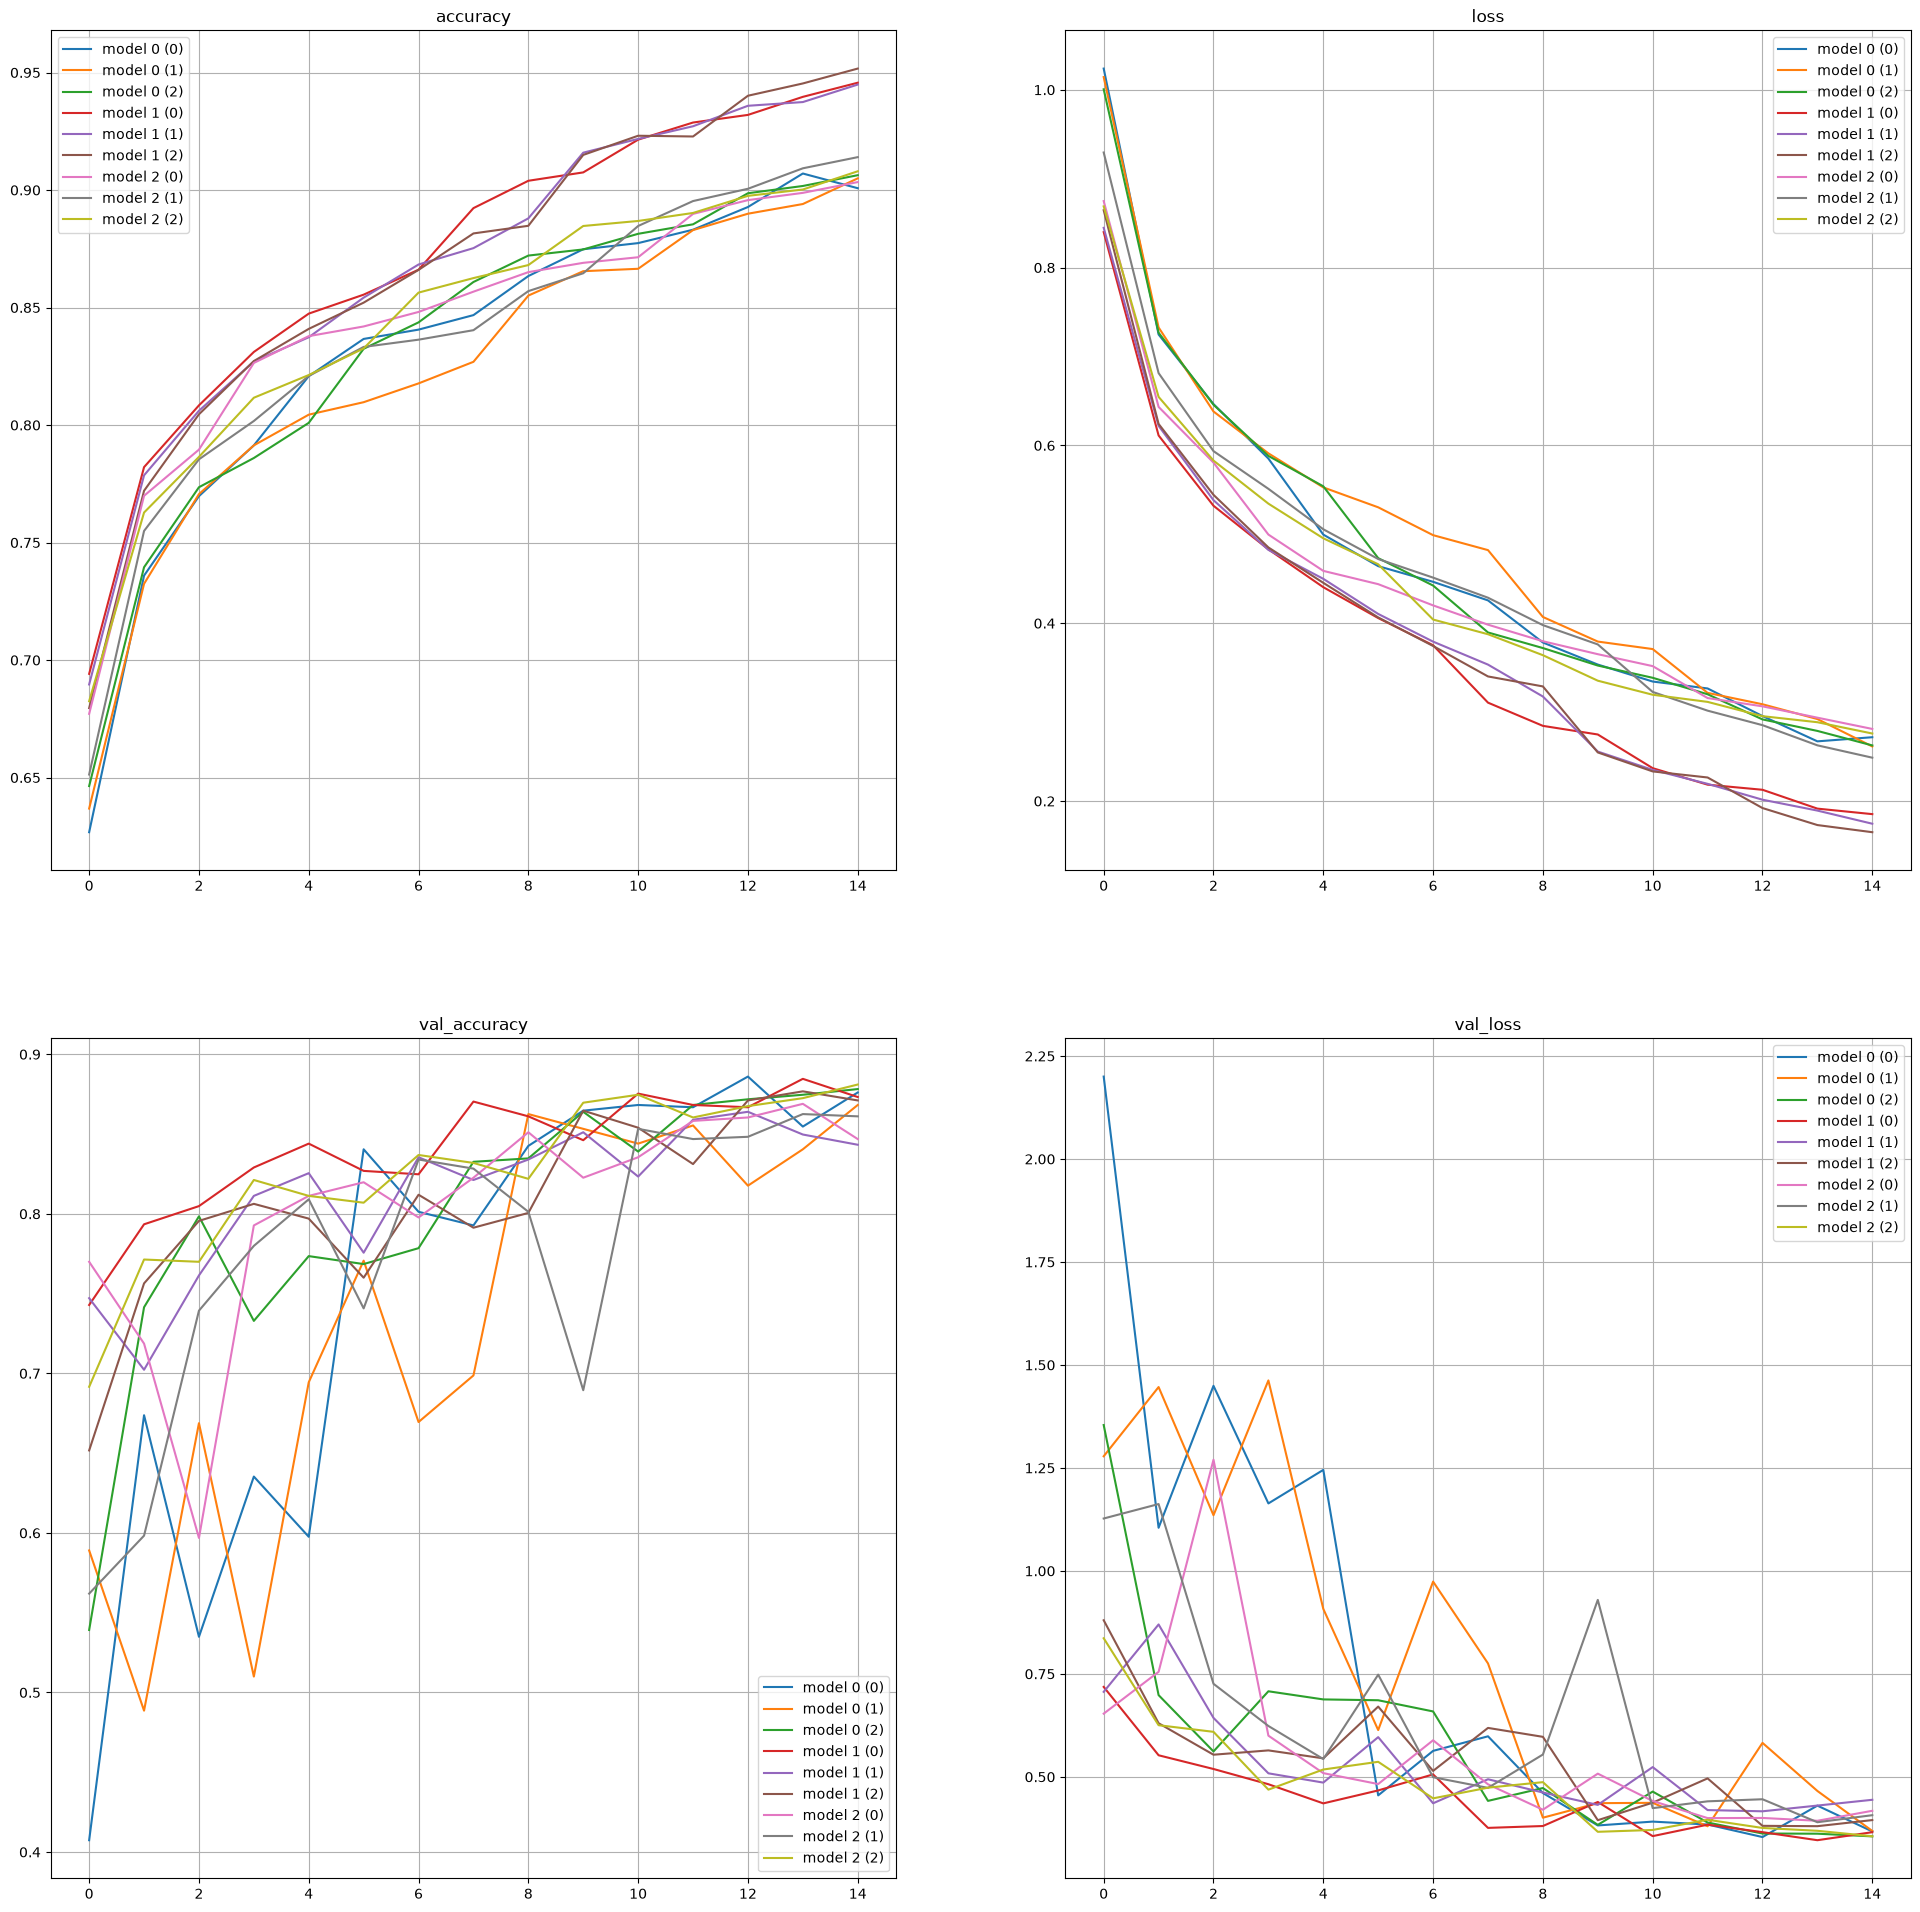

In [38]:
fig, ax = plt.subplots(2, 2, figsize=(24, 24))
for i, metric in enumerate(["accuracy", "loss", "val_accuracy", "val_loss"]):
    axis = ax[i//2][i%2]
    for j, settings in tune_params[:3].iterrows():
        for k in range(3):
            axis.plot(settings["3_model_history"][k].epoch, settings["3_model_history"][k].history[metric], label=f"model {j} ({k})")
        axis.set_title(metric)
        axis.grid(True)
        axis.legend()

plt.show()

In [40]:
best_id = [0,1,2]

top_3 = tune_params.iloc[best_id].sort_values("val_acc", ignore_index=True)
top_3

,name,model,architecture,param,loss,accuracy,config,learning_rate,drop_rate,rotation,zoom,contrast,translation,history,val_acc,val_loss,avg_models,3_model_history,avg_val_acc,avg_val_loss
0,model_1_5,"<Sequential name=sequential_7, built=True>",1,<keras_tuner.src.engine.hyperparameters.hyperp...,0.464251,0.837667,config3,0.000224,0.1,0.0,0.05,0.05,0.0,<keras.src.callbacks.history.History object at...,0.863248,0.402934,"<Sequential name=sequential_91, built=True>",[<keras.src.callbacks.history.History object a...,0.870845,0.379625
1,model_1_8,"<Sequential name=sequential_11, built=True>",1,<keras_tuner.src.engine.hyperparameters.hyperp...,0.509797,0.827333,config3,0.000224,0.1,0.0,0.00,0.15,0.0,<keras.src.callbacks.history.History object at...,0.869658,0.367408,"<Sequential name=sequential_85, built=True>",[<keras.src.callbacks.history.History object a...,0.873219,0.381198
2,model_1_0,"<Sequential name=sequential_5, built=True>",1,<keras_tuner.src.engine.hyperparameters.hyperp...,0.462512,0.844000,config0,0.001778,0.5,0.0,0.05,0.10,0.0,<keras.src.callbacks.history.History object at...,0.898148,0.330171,"<Sequential name=sequential_61, built=True>",[<keras.src.callbacks.history.History object a...,0.877493,0.359313


In [ ]:
os.makedirs(os.path.join(os.path.curdir, "selected models"),exist_ok=True)

for i, settings in top_3.iterrows():
    path = os.path.join(os.path.curdir, "selected models", f"model_{i}")
    os.makedirs(path, exist_ok=True)

    with open(os.path.join(path, "architecture.json"), "w") as f:
        f.write(settings["model"].to_json())
    settings.astype(str).to_json(os.path.join(path, "hyperparameters.json"), )


    settings["model"].save(os.path.join(path, "model.keras"))
    settings["model"].save_weights(os.path.join(path, "weights.weights.h5"))

name                                                       model_1_5
model                     <Sequential name=sequential_7, built=True>
architecture                                                       1
param              <keras_tuner.src.engine.hyperparameters.hyperp...
loss                                                        0.464251
accuracy                                                    0.837667
config                                                       config3
learning_rate                                               0.000224
drop_rate                                                        0.1
rotation                                                         0.0
zoom                                                            0.05
contrast                                                        0.05
translation                                                      0.0
history            <keras.src.callbacks.history.History object at...
val_acc                           

# Fine tuning final models

Run the imports and dataset-loading cells before this section. Load the selected
configurations and saved weights from `selected models/model_*`; earlier searches
do not need to be rerun.

Keep the architecture, augmentation, dropout and learning rate fixed for each
selected model. Tune the L2 **weight regularization** coefficient on every Conv2D
and Dense kernel, including a zero-penalty baseline. Each trial starts from the
same saved weights for its selected model, with a fresh optimizer.

Use the same validation split as the earlier training so that saved models have
not trained on the validation examples. Rank trials by validation accuracy; use
the test set only after choosing the final model.

In [53]:
import json
from pathlib import Path

selected_models_dir = Path("selected models")
selected_configs = {}
float_params = ("learning_rate", "drop_rate", "rotation", "zoom", "contrast", "translation")

for model_dir in sorted(selected_models_dir.glob("model_*")):
    if not model_dir.is_dir():
        continue
    with (model_dir / "hyperparameters.json").open() as f:
        saved_params = json.load(f)

    # These values were exported as strings by the selection section.
    config = {key: float(saved_params[key]) for key in float_params}
    config["architecture"] = int(saved_params["architecture"])
    if config["architecture"] not in (0, 1):
        raise ValueError(f"Unsupported architecture in {model_dir}")
    config["weights_path"] = str(model_dir / "weights.weights.h5")
    if not Path(config["weights_path"]).is_file():
        raise FileNotFoundError(config["weights_path"])
    selected_configs[model_dir.name] = config

if not selected_configs:
    raise FileNotFoundError("No selected models found in selected models/model_*")

L2_VALUES = [0.0, 1e-6, 1e-5, 1e-4, 3e-4, 1e-3, 1e-2]
FINAL_EPOCHS = 15
FINAL_BATCH_SIZE = 32

pd.DataFrame.from_dict(selected_configs, orient="index")

,learning_rate,drop_rate,rotation,zoom,contrast,translation,architecture,weights_path
model_0,0.000224,0.1,0.0,0.05,0.05,0.0,1,selected models/model_0/weights.weights.h5
model_1,0.000224,0.1,0.0,0.00,0.15,0.0,1,selected models/model_1/weights.weights.h5
model_2,0.001778,0.5,0.0,0.05,0.10,0.0,1,selected models/model_2/weights.weights.h5


In [54]:
def build_model(hp):
    """Rebuild a selected CNN with L2 and restore its pretrained weights."""
    config_name = hp.Choice("selected_model", values=list(selected_configs))
    l2_value = hp.Choice("l2", values=L2_VALUES)
    config = selected_configs[config_name]
    regularizer = keras.regularizers.l2(l2_value)

    augmentation = keras.Sequential([
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(config["rotation"]),
        keras.layers.RandomZoom(config["zoom"]),
        keras.layers.RandomContrast(config["contrast"]),
        keras.layers.RandomTranslation(config["translation"], config["translation"]),
    ], name="augmentation")

    model = keras.Sequential([
        keras.Input(shape=(64, 64, 3)),
        augmentation,
    ])
    for index, filters in enumerate([32, 64, 128, 256]):
        model.add(keras.layers.Conv2D(
            filters, 3, activation="relu",
            padding="same" if index == 0 else "valid",
            kernel_regularizer=regularizer,
        ))
        if config["architecture"] == 1:
            model.add(keras.layers.BatchNormalization())
        if index < 3:
            model.add(keras.layers.MaxPooling2D((2, 2)))

    model.add(keras.layers.GlobalAveragePooling2D())
    model.add(keras.layers.Dropout(config["drop_rate"]))
    model.add(keras.layers.Dense(
        len(labels), activation="softmax", kernel_regularizer=regularizer,
    ))

    # Load before compiling: keep learned weights and BN statistics, but reset Adam.
    # Reload for every trial so one L2 candidate cannot train another's starting point.
    model.load_weights(config["weights_path"])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config["learning_rate"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [56]:
class HistoryGridSearch(kt.GridSearch):
    """Save per-epoch curves; the tuner's trial metrics only retain a summary."""
    def run_trial(self, trial, *args, **kwargs):
        callbacks = list(kwargs.pop("callbacks", []))
        callbacks.append(keras.callbacks.CSVLogger(
            str(Path(self.get_trial_dir(trial.trial_id)) / "history.csv"),
            append=False,
        ))
        return super().run_trial(trial, *args, callbacks=callbacks, **kwargs)


# Preserve the original split used to train the selected checkpoints.
x_train, x_val, y_train, y_val = train_test_split(
    train_x, train_y, test_size=0.1, random_state=42, shuffle=False,
)
keras.utils.set_random_seed(42)

final_tuner = HistoryGridSearch(
    hypermodel=build_model,
    objective=kt.Objective("val_accuracy", direction="max"),
    max_trials=len(selected_configs) * len(L2_VALUES),
    seed=42,
    directory="CNN_search_final",
    project_name="selected_models_l2",
    overwrite=False,  # Resume this grid; use a new project name if inputs/grid change.
)
reseed_grid_picker(final_tuner)
final_tuner.search_space_summary()

final_tuner.search(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=FINAL_EPOCHS,
    batch_size=FINAL_BATCH_SIZE,
    shuffle=True,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy", mode="max", patience=5,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6,
        ),
    ],
    verbose=1,
)

Reloading Tuner from CNN_search_final/selected_models_l2/tuner0.json
Search space summary
Default search space size: 2
selected_model (Choice)
{'default': 'model_0', 'conditions': [], 'values': ['model_0', 'model_1', 'model_2'], 'ordered': False}
l2 (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 1e-06, 1e-05, 0.0001, 0.0003, 0.001, 0.01], 'ordered': True}


In [57]:
final_tuner.results_summary()
final_results = pd.DataFrame([
    {
        "trial_id": trial.trial_id,
        "selected_model": trial.hyperparameters["selected_model"],
        "l2": trial.hyperparameters["l2"],
        "val_accuracy": trial.score,
        "best_epoch": trial.best_step + 1,
    }
    for trial in final_tuner.oracle.trials.values()
    if trial.status == "COMPLETED" and trial.score is not None
]).sort_values("val_accuracy", ascending=False, ignore_index=True)

final_results

Results summary
Results in CNN_search_final/selected_models_l2
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 18 summary
Hyperparameters:
selected_model: model_2
l2: 0.0003
Score: 0.8782051205635071

Trial 00 summary
Hyperparameters:
selected_model: model_0
l2: 0.0
Score: 0.87678062915802

Trial 07 summary
Hyperparameters:
selected_model: model_1
l2: 0.0
Score: 0.8760683536529541

Trial 08 summary
Hyperparameters:
selected_model: model_1
l2: 1e-06
Score: 0.8739316463470459

Trial 04 summary
Hyperparameters:
selected_model: model_0
l2: 0.0003
Score: 0.87321937084198

Trial 10 summary
Hyperparameters:
selected_model: model_1
l2: 0.0001
Score: 0.8725070953369141

Trial 03 summary
Hyperparameters:
selected_model: model_0
l2: 0.0001
Score: 0.8717948794364929

Trial 12 summary
Hyperparameters:
selected_model: model_1
l2: 0.001
Score: 0.8717948794364929

Trial 01 summary
Hyperparameters:
selected_model: model_0
l2: 1e-06
Score: 0.8717948794364929

Trial 09 summa

,trial_id,selected_model,l2,val_accuracy,best_epoch
0,18,model_2,0.000300,0.878205,14
1,00,model_0,0.000000,0.876781,15
2,07,model_1,0.000000,0.876068,15
3,08,model_1,0.000001,0.873932,14
4,04,model_0,0.000300,0.873219,12
5,10,model_1,0.000100,0.872507,11
6,01,model_0,0.000001,0.871795,14
7,12,model_1,0.001000,0.871795,9
8,03,model_0,0.000100,0.871795,15
9,09,model_1,0.000010,0.871083,5


## Inspect and extend the top five models

Run this section after the final grid search finishes. Future searches save full
curves in each trial's `history.csv`. Existing completed trials without those files
only have a best-epoch observation, which is shown as a point, not a learning curve.
For those trials, run a **10-epoch diagnostic continuation** from their best search
checkpoint to collect new curves; these are not the original search histories.

The diagnostic table flags models whose recent validation accuracy rises, or whose
validation loss falls without an accuracy drop. This is a heuristic for deciding
whether more training may help, not a guarantee. Inspect the plots and optionally
add trial IDs to `FORCE_CONTINUE_TRIALS`. Promising candidates continue for up to
100 additional epochs in total, with learning-rate reduction and early stopping.
Every candidate keeps its original search checkpoint unless validation accuracy
improves. Select among all five candidates before evaluating the test set.

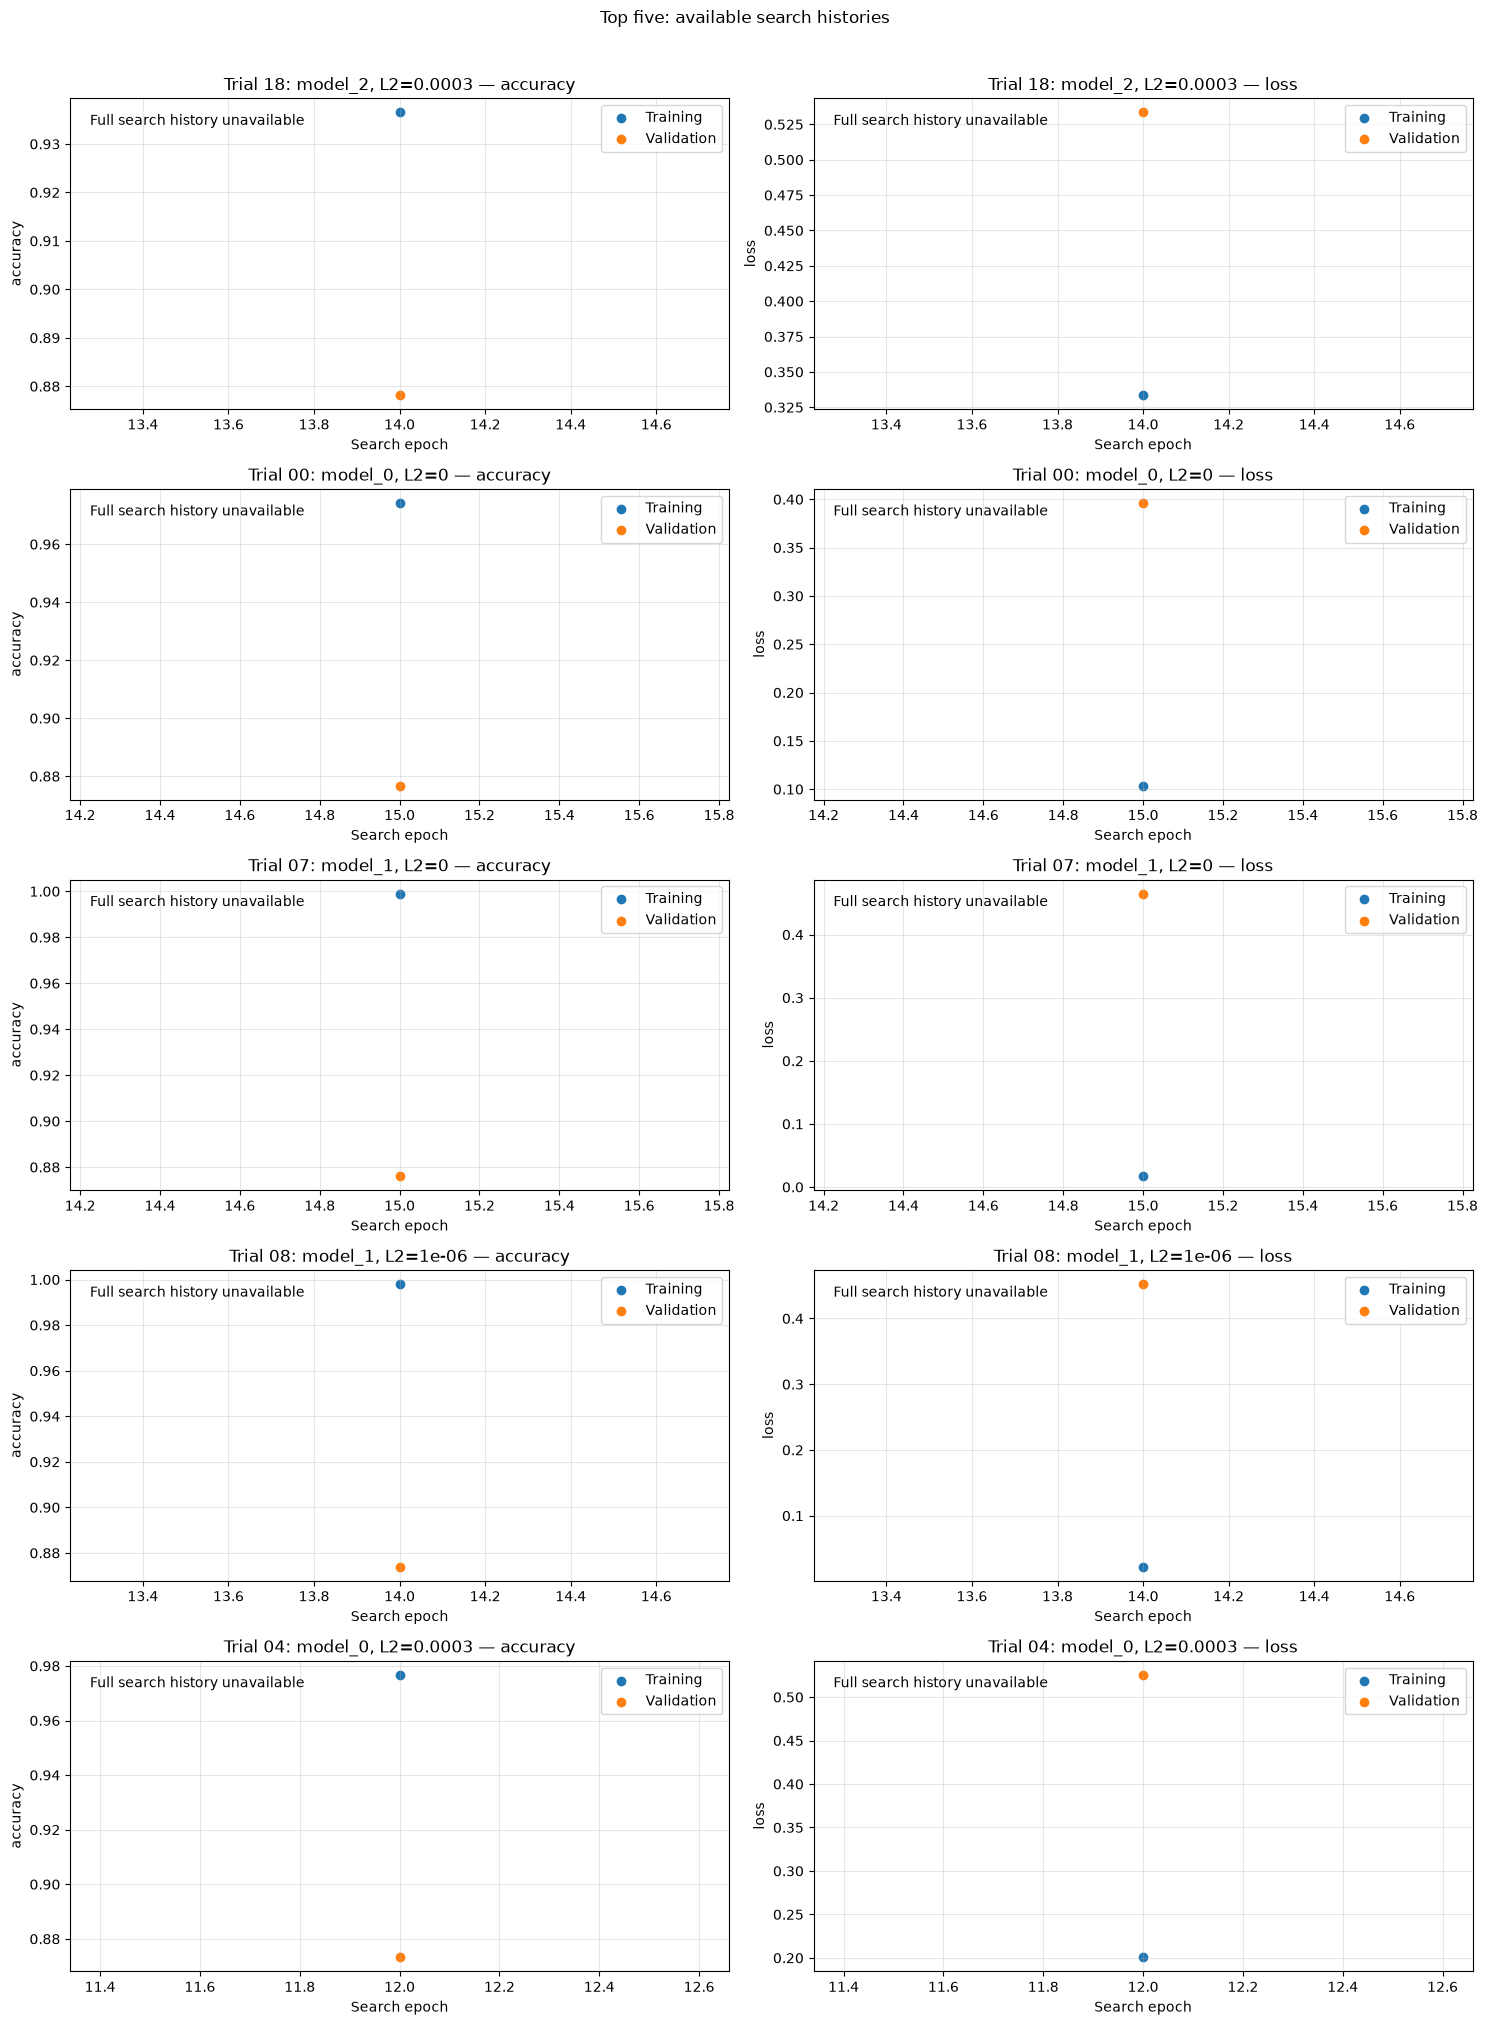

In [58]:
from datetime import datetime

TOP_MODELS = 5
PROBE_EPOCHS = 10
MAX_EXTRA_EPOCHS = 50  # Includes diagnostic epochs for models missing histories.
LONG_PATIENCE = 15
TREND_WINDOW = 3
ACCURACY_MIN_DELTA = 1e-3

completed_trials = [
    trial for trial in final_tuner.oracle.trials.values()
    if trial.status == "COMPLETED" and trial.score is not None
]
top_trials = sorted(completed_trials, key=lambda trial: trial.score, reverse=True)[:TOP_MODELS]
if not top_trials:
    raise RuntimeError("Finish the final grid search before inspecting its top models.")

# A separate directory preserves both the search and previous continuation runs.
continuation_dir = Path("fine_tune_best") / "final_l2" / datetime.now().strftime("top5_%Y%m%d_%H%M%S_%f")
continuation_dir.mkdir(parents=True, exist_ok=True)
search_histories = {}
continuation_histories = {}
candidates = {}


def plot_top_histories(histories, title, output_name, original_search=False):
    fig, axes = plt.subplots(len(top_trials), 2, figsize=(15, 4 * len(top_trials)), squeeze=False)
    for row, trial in enumerate(top_trials):
        trial_id = trial.trial_id
        hp = trial.hyperparameters
        history = histories.get(trial_id)
        label = f"Trial {trial_id}: {hp['selected_model']}, L2={hp['l2']:g}"
        for col, metric in enumerate(["accuracy", "loss"]):
            axis = axes[row, col]
            if history is not None and not history.empty:
                epochs = history["epoch"] + 1
                axis.plot(epochs, history[metric], label="Training")
                axis.plot(epochs, history[f"val_{metric}"], label="Validation")
                best = history.loc[history["val_accuracy"].idxmax(), "epoch"] + 1
                axis.axvline(best, color="gray", linestyle=":", label="Best validation accuracy")
            elif original_search:
                # A single recorded observation cannot establish a trend.
                for key, legend in [(metric, "Training"), (f"val_{metric}", "Validation")]:
                    observations = trial.metrics.get_history(key) if trial.metrics.exists(key) else []
                    axis.scatter([item.step + 1 for item in observations],
                                 [float(np.mean(item.value)) for item in observations], label=legend)
                axis.text(0.03, 0.95, "Full search history unavailable", transform=axis.transAxes, va="top")
            else:
                axis.text(0.5, 0.5, "No extra training: retained search checkpoint",
                          transform=axis.transAxes, ha="center")
            axis.set_title(f"{label} — {metric}")
            axis.set_xlabel("Search epoch" if original_search else "Additional training epoch")
            axis.set_ylabel(metric)
            axis.grid(alpha=0.3)
            if axis.get_legend_handles_labels()[0]:
                axis.legend()
    fig.suptitle(title, y=1.01)
    fig.tight_layout()
    fig.savefig(continuation_dir / output_name, dpi=150, bbox_inches="tight")
    plt.show()


def continuation_callbacks(checkpoint_path, baseline_accuracy, history_path, append=False):
    return [
        keras.callbacks.ModelCheckpoint(
            str(checkpoint_path), monitor="val_accuracy", mode="max", save_best_only=True,
            initial_value_threshold=baseline_accuracy,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy", mode="max", patience=LONG_PATIENCE,
            min_delta=ACCURACY_MIN_DELTA,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7,
        ),
        keras.callbacks.CSVLogger(str(history_path), append=append),
    ]


for trial in top_trials:
    history_path = Path(final_tuner.get_trial_dir(trial.trial_id)) / "history.csv"
    if history_path.exists():
        search_histories[trial.trial_id] = pd.read_csv(history_path)

plot_top_histories(search_histories, "Top five: available search histories", "search_histories.png", original_search=True)

/home/nilesh/miniconda3/envs/tf220/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(store)


Trial 18: collecting 10 new diagnostic epochs
Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9430 - loss: 0.3129 - val_accuracy: 0.8704 - val_loss: 0.5777 - learning_rate: 2.2228e-04
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9448 - loss: 0.3036 - val_accuracy: 0.8711 - val_loss: 0.5723 - learning_rate: 2.2228e-04
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9498 - loss: 0.2894 - val_accuracy: 0.8540 - val_loss: 0.6284 - learning_rate: 2.2228e-04
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9517 - loss: 0.2806 - val_accuracy: 0.8597 - val_loss: 0.6325 - learning_rate: 2.2228e-04
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9530 - loss: 0.2724 - val_accuracy: 0.8291 - val_loss: 0.7435 - learning_rate: 2.2228e-04
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9587 - loss: 0.2600 - val_accuracy: 0.8668 - val_loss: 0.5934 - learning_rate: 2.2228e-04
Epoch 7/10
3

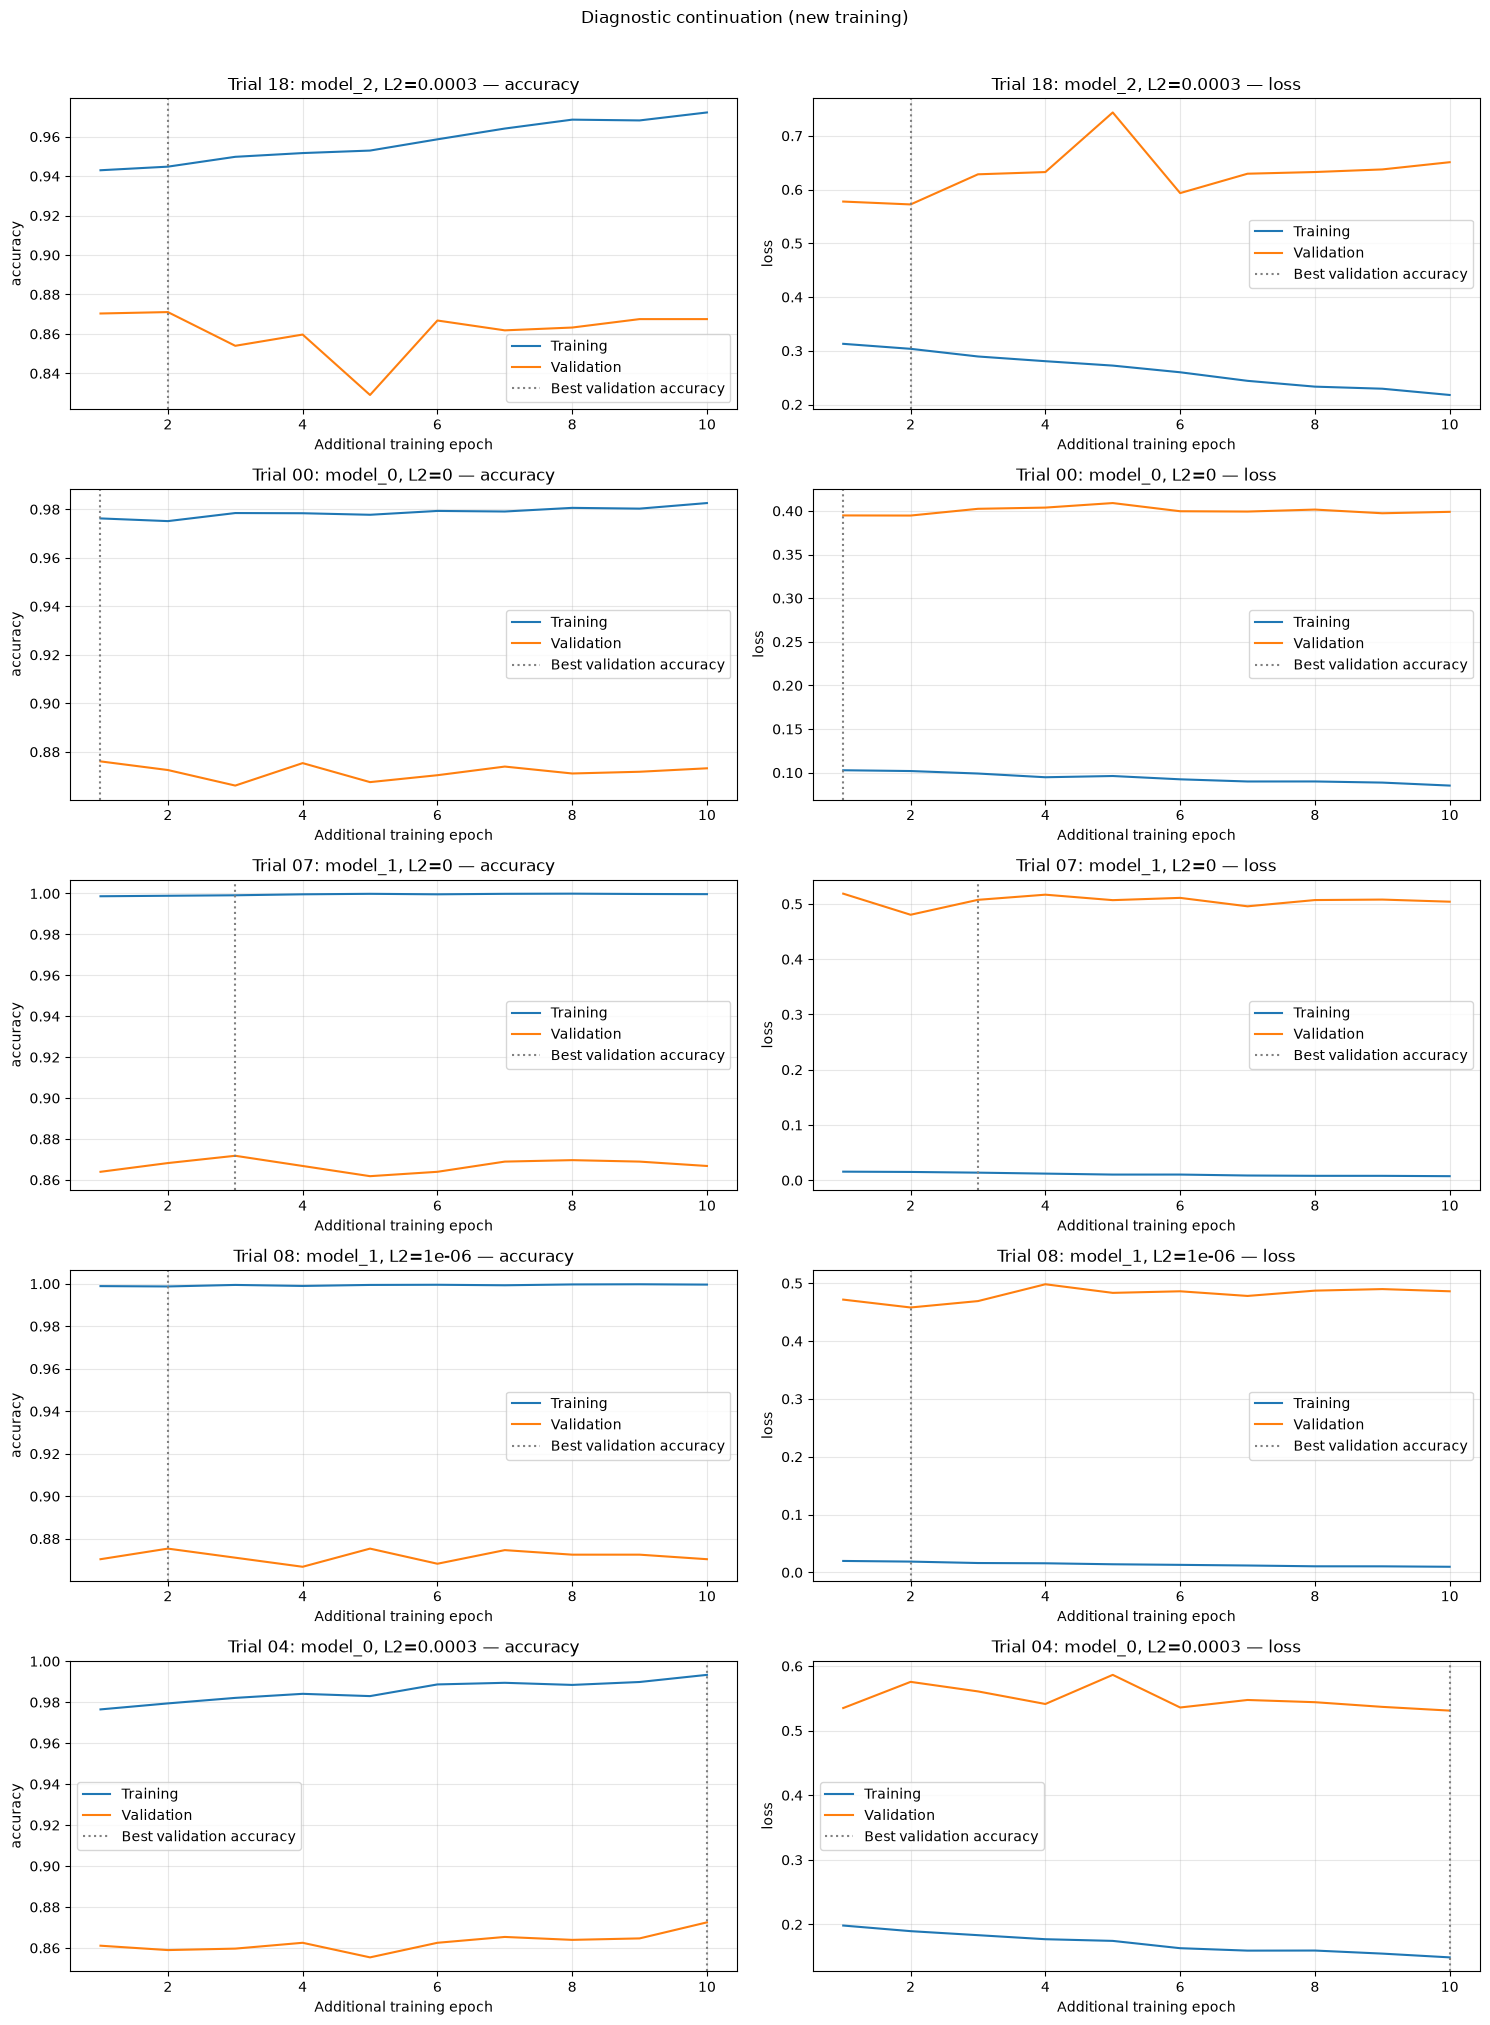

In [59]:
# Seed each candidate with its best search checkpoint. Probe only missing histories.
for trial in top_trials:
    trial_id = trial.trial_id
    keras.backend.clear_session()
    keras.utils.set_random_seed(42)
    model = final_tuner.load_model(trial)
    trial_dir = continuation_dir / f"trial_{trial_id}"
    trial_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = trial_dir / "best.keras"
    history_path = trial_dir / "continuation.csv"

    # KerasTuner may restore weights with a fresh optimizer. Set an explicit,
    # conservative continuation LR using the recorded best search epoch.
    hp = trial.hyperparameters
    search_lr = (trial.metrics.get_best_value("learning_rate")
                 if trial.metrics.exists("learning_rate") else None)
    learning_rate = float(search_lr) if search_lr is not None else selected_configs[hp["selected_model"]]["learning_rate"] * 0.1
    model.optimizer.learning_rate.assign(learning_rate)
    baseline = model.evaluate(x_val, y_val, batch_size=FINAL_BATCH_SIZE, verbose=0, return_dict=True)
    model.save(checkpoint_path)
    candidates[trial_id] = {
        "trial_id": trial_id,
        "selected_model": hp["selected_model"], "l2": hp["l2"],
        "search_val_accuracy": float(baseline["accuracy"]),
        "checkpoint_path": str(checkpoint_path),
        "history_path": str(history_path),
        "extra_epochs": 0,
    }

    if trial_id not in search_histories:
        print(f"Trial {trial_id}: collecting {PROBE_EPOCHS} new diagnostic epochs")
        history = model.fit(
            x_train, y_train, validation_data=(x_val, y_val),
            epochs=PROBE_EPOCHS, batch_size=FINAL_BATCH_SIZE, shuffle=True,
            callbacks=continuation_callbacks(checkpoint_path, baseline["accuracy"], history_path),
            verbose=1,
        )
        frame = pd.DataFrame(history.history)
        frame.insert(0, "epoch", history.epoch)
        continuation_histories[trial_id] = frame
        candidates[trial_id]["extra_epochs"] = len(frame)
    del model

plot_top_histories(continuation_histories, "Diagnostic continuation (new training)", "diagnostic_histories.png")

In [60]:
def assess_history(frame):
    """Compare two recent windows; do not extrapolate from a single best epoch."""
    if frame is None or len(frame) < 2 * TREND_WINDOW:
        return {"continue_training": False, "reason": "Too few epochs to assess", "accuracy_gain": np.nan, "loss_drop": np.nan}
    earlier = frame.iloc[-2 * TREND_WINDOW:-TREND_WINDOW]
    recent = frame.iloc[-TREND_WINDOW:]
    accuracy_gain = float(recent.val_accuracy.mean() - earlier.val_accuracy.mean())
    loss_drop = float(earlier.val_loss.mean() - recent.val_loss.mean())
    improving = accuracy_gain >= ACCURACY_MIN_DELTA or (
        loss_drop > max(1e-4, 0.005 * abs(float(earlier.val_loss.mean())))
        and accuracy_gain >= -ACCURACY_MIN_DELTA
    )
    return {
        "continue_training": improving,
        "reason": "Validation still improving" if improving else "Validation plateau or deterioration",
        "accuracy_gain": accuracy_gain,
        "loss_drop": loss_drop,
        "train_val_gap": float(recent.accuracy.mean() - recent.val_accuracy.mean()),
    }


diagnostics = []
for trial in top_trials:
    trial_id = trial.trial_id
    is_probe = trial_id in continuation_histories
    frame = continuation_histories.get(trial_id) if is_probe else search_histories.get(trial_id)
    diagnostics.append({
        "trial_id": trial_id,
        "history_source": "Diagnostic continuation" if is_probe else "Original search",
        **assess_history(frame),
    })
diagnostics = pd.DataFrame(diagnostics)
diagnostics.to_csv(continuation_dir / "diagnostics.csv", index=False)
diagnostics

,trial_id,history_source,continue_training,reason,accuracy_gain,loss_drop,train_val_gap
0,18,Diagnostic continuation,True,Validation still improving,0.013533,0.015128,0.103631
1,00,Diagnostic continuation,True,Validation still improving,0.001424,0.003369,0.109124
2,07,Diagnostic continuation,True,Validation still improving,0.003561,-0.001822,0.131318
3,08,Diagnostic continuation,False,Validation plateau or deterioration,-0.000950,-0.005239,0.127888
4,04,Diagnostic continuation,True,Validation still improving,0.005935,0.019262,0.123505


/home/nilesh/miniconda3/envs/tf220/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(store)


Trial 18: training up to 50 additional epochs in total
Epoch 11/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9434 - loss: 0.3128 - val_accuracy: 0.8711 - val_loss: 0.5783 - learning_rate: 2.2228e-04
Epoch 12/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9452 - loss: 0.3039 - val_accuracy: 0.8746 - val_loss: 0.5710 - learning_rate: 2.2228e-04
Epoch 13/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9496 - loss: 0.2892 - val_accuracy: 0.8604 - val_loss: 0.6248 - learning_rate: 2.2228e-04
Epoch 14/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9523 - loss: 0.2798 - val_accuracy: 0.8611 - val_loss: 0.6020 - learning_rate: 2.2228e-04
Epoch 15/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9533 - loss: 0.2717 - val_accuracy: 0.8490 - val_loss: 0.6478 - learning_rate: 2.2228e-04
Epoch 16/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9580 - loss: 0.2596 - val_accuracy: 0.8668 - val_loss: 0.5915 - learning_rate: 2.2228e-

/home/nilesh/miniconda3/envs/tf220/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(store)


Trial 00: training up to 50 additional epochs in total
Epoch 11/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9762 - loss: 0.1028 - val_accuracy: 0.8754 - val_loss: 0.3946 - learning_rate: 1.3992e-05
Epoch 12/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9751 - loss: 0.1018 - val_accuracy: 0.8725 - val_loss: 0.3945 - learning_rate: 1.3992e-05
Epoch 13/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9785 - loss: 0.0990 - val_accuracy: 0.8661 - val_loss: 0.4028 - learning_rate: 1.3992e-05
Epoch 14/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9785 - loss: 0.0948 - val_accuracy: 0.8761 - val_loss: 0.4039 - learning_rate: 1.3992e-05
Epoch 15/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9779 - loss: 0.0962 - val_accuracy: 0.8682 - val_loss: 0.4089 - learning_rate: 1.3992e-05
Epoch 16/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9792 - loss: 0.0913 - val_accuracy: 0.8718 - val_loss: 0.3967 - learning_rate: 6.9960e-

/home/nilesh/miniconda3/envs/tf220/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(store)


Trial 07: training up to 50 additional epochs in total
Epoch 11/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9987 - loss: 0.0156 - val_accuracy: 0.8640 - val_loss: 0.5190 - learning_rate: 2.7984e-05
Epoch 12/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9989 - loss: 0.0151 - val_accuracy: 0.8697 - val_loss: 0.4801 - learning_rate: 2.7984e-05
Epoch 13/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9991 - loss: 0.0138 - val_accuracy: 0.8697 - val_loss: 0.5058 - learning_rate: 2.7984e-05
Epoch 14/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9995 - loss: 0.0121 - val_accuracy: 0.8668 - val_loss: 0.5178 - learning_rate: 2.7984e-05
Epoch 15/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9998 - loss: 0.0103 - val_accuracy: 0.8611 - val_loss: 0.5096 - learning_rate: 2.7984e-05
Epoch 16/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9996 - loss: 0.0103 - val_accuracy: 0.8661 - val_loss: 0.5104 - learning_rate: 2.7984e-

/home/nilesh/miniconda3/envs/tf220/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(store)


Trial 04: training up to 50 additional epochs in total
Epoch 11/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9769 - loss: 0.1983 - val_accuracy: 0.8597 - val_loss: 0.5364 - learning_rate: 5.5968e-05
Epoch 12/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9794 - loss: 0.1897 - val_accuracy: 0.8618 - val_loss: 0.5747 - learning_rate: 5.5968e-05
Epoch 13/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9823 - loss: 0.1834 - val_accuracy: 0.8604 - val_loss: 0.5608 - learning_rate: 5.5968e-05
Epoch 14/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9836 - loss: 0.1772 - val_accuracy: 0.8675 - val_loss: 0.5420 - learning_rate: 5.5968e-05
Epoch 15/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9831 - loss: 0.1747 - val_accuracy: 0.8540 - val_loss: 0.5954 - learning_rate: 5.5968e-05
Epoch 16/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9895 - loss: 0.1632 - val_accuracy: 0.8654 - val_loss: 0.5320 - learning_rate: 2.7984e-

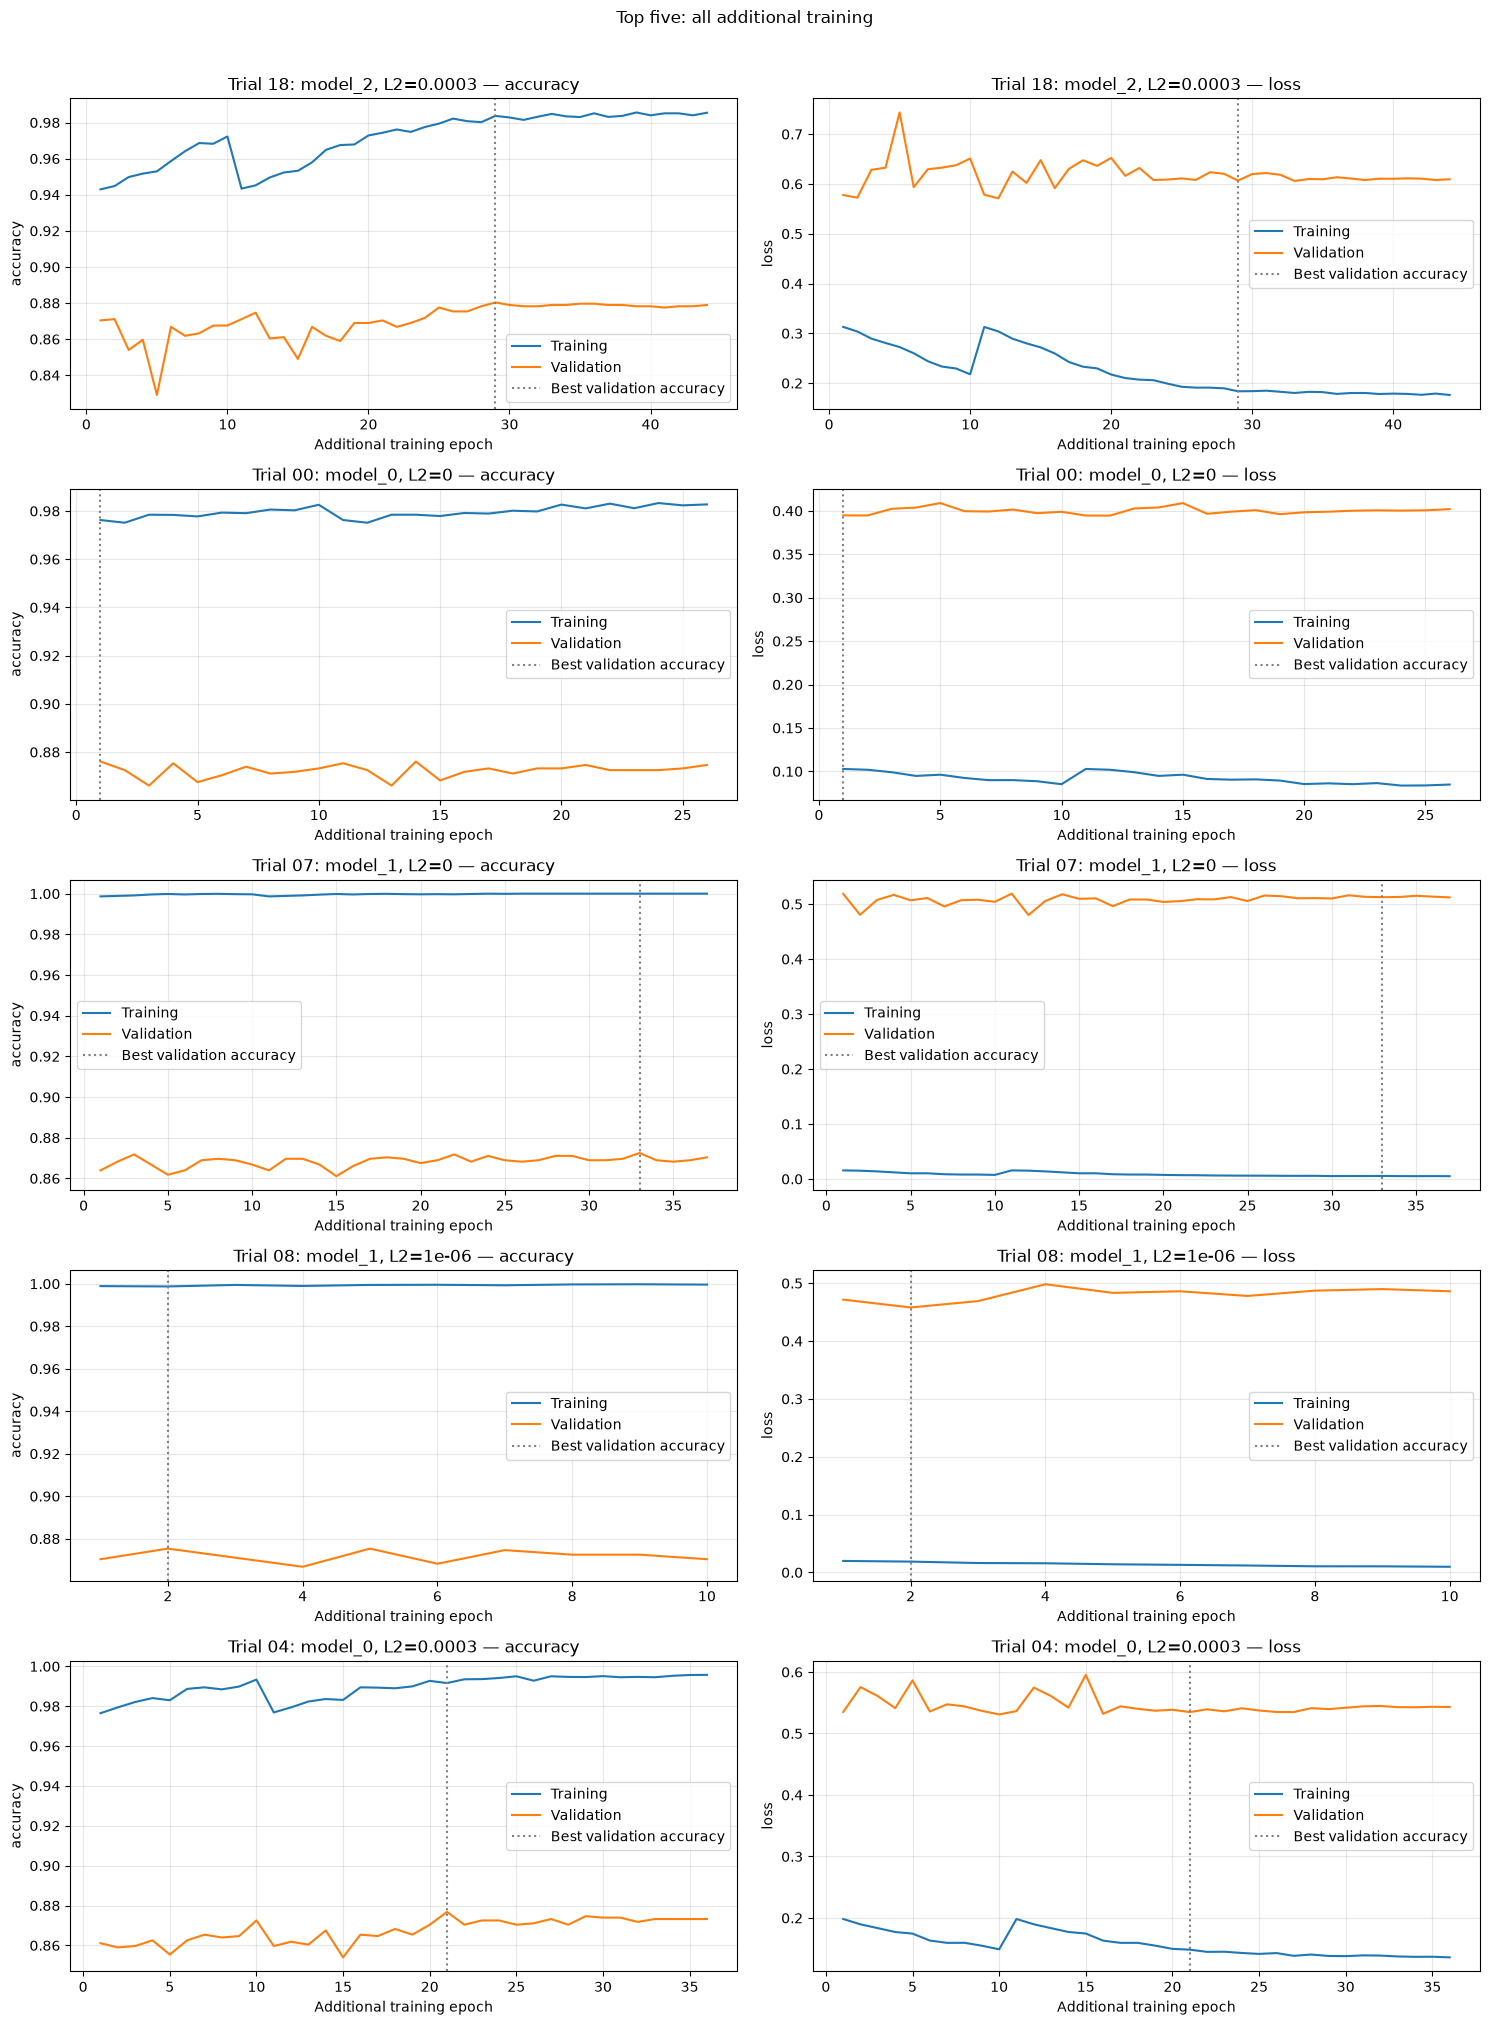

In [62]:
# Optionally include trial IDs after inspecting the curves, e.g. {"00", "18"}.
FORCE_CONTINUE_TRIALS = set()
continue_ids = set(diagnostics.loc[diagnostics.continue_training, "trial_id"]) | FORCE_CONTINUE_TRIALS
unknown_ids = continue_ids - set(candidates)
if unknown_ids:
    raise ValueError(f"Trial IDs are not in the top five: {unknown_ids}")

for trial in top_trials:
    trial_id = trial.trial_id
    candidate = candidates[trial_id]
    if trial_id not in continue_ids or candidate["extra_epochs"] >= MAX_EXTRA_EPOCHS:
        continue
    keras.backend.clear_session()
    keras.utils.set_random_seed(42)
    model = keras.models.load_model(candidate["checkpoint_path"])
    baseline = model.evaluate(x_val, y_val, batch_size=FINAL_BATCH_SIZE, verbose=0, return_dict=True)
    print(f"Trial {trial_id}: training up to {MAX_EXTRA_EPOCHS} additional epochs in total")
    history = model.fit(
        x_train, y_train, validation_data=(x_val, y_val),
        initial_epoch=candidate["extra_epochs"], epochs=MAX_EXTRA_EPOCHS,
        batch_size=FINAL_BATCH_SIZE, shuffle=True,
        callbacks=continuation_callbacks(
            candidate["checkpoint_path"], baseline["accuracy"], candidate["history_path"],
            append=candidate["extra_epochs"] > 0,
        ),
        verbose=1,
    )
    frame = pd.DataFrame(history.history)
    frame.insert(0, "epoch", history.epoch)
    previous = continuation_histories.get(trial_id, pd.DataFrame())
    continuation_histories[trial_id] = pd.concat([previous, frame], ignore_index=True)
    candidate["extra_epochs"] += len(frame)
    del model

plot_top_histories(continuation_histories, "Top five: all additional training", "extended_histories.png")

In [63]:
# Include candidates that plateaued: their original checkpoints may still win.
long_results = []
for trial in top_trials:
    candidate = candidates[trial.trial_id]
    keras.backend.clear_session()
    model = keras.models.load_model(candidate["checkpoint_path"])
    metrics = model.evaluate(x_val, y_val, batch_size=FINAL_BATCH_SIZE, verbose=0, return_dict=True)
    long_results.append({
        **candidate,
        "val_accuracy": float(metrics["accuracy"]),
        "val_loss": float(metrics["loss"]),
        "accuracy_improvement": float(metrics["accuracy"]) - candidate["search_val_accuracy"],
    })
    del model

long_results = pd.DataFrame(long_results).sort_values(
    "val_accuracy", ascending=False, ignore_index=True,
)
long_results.to_csv(continuation_dir / "model_comparison.csv", index=False)
long_results

/home/nilesh/miniconda3/envs/tf220/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(store)


,trial_id,selected_model,l2,search_val_accuracy,checkpoint_path,history_path,extra_epochs,val_accuracy,val_loss,accuracy_improvement
0,18,model_2,0.000300,0.878205,fine_tune_best/final_l2/top5_20260928_183441_1...,fine_tune_best/final_l2/top5_20260928_183441_1...,44,0.880342,0.606642,0.002137
1,00,model_0,0.000000,0.876781,fine_tune_best/final_l2/top5_20260928_183441_1...,fine_tune_best/final_l2/top5_20260928_183441_1...,26,0.876781,0.396131,0.000000
2,04,model_0,0.000300,0.873219,fine_tune_best/final_l2/top5_20260928_183441_1...,fine_tune_best/final_l2/top5_20260928_183441_1...,36,0.876781,0.534841,0.003561
3,07,model_1,0.000000,0.876068,fine_tune_best/final_l2/top5_20260928_183441_1...,fine_tune_best/final_l2/top5_20260928_183441_1...,37,0.876068,0.464994,0.000000
4,08,model_1,0.000001,0.873932,fine_tune_best/final_l2/top5_20260928_183441_1...,fine_tune_best/final_l2/top5_20260928_183441_1...,10,0.875356,0.458065,0.001424


In [65]:
# Test only the winner selected by validation accuracy.
winner = long_results.iloc[0]
final_model = keras.models.load_model(winner["checkpoint_path"])
final_test_metrics = final_model.evaluate(test_x, test_y, batch_size=FINAL_BATCH_SIZE, verbose=0, return_dict=True)
# Keep the deployable model artifacts together, separate from training reports.
best_model_dir = continuation_dir / "best_model"
best_model_dir.mkdir(parents=True, exist_ok=True)
final_model.save(best_model_dir / "model.keras")
final_model.save_weights(best_model_dir / "weights.weights.h5")
with (best_model_dir / "architecture.json").open("w") as f:
    f.write(final_model.to_json())
final_results.to_csv(continuation_dir / "grid_results.csv", index=False)
final_params = {
    **selected_configs[winner["selected_model"]],
    "source_weights_path": selected_configs[winner["selected_model"]]["weights_path"],
    "weights_path": "weights.weights.h5",
    "model_path": "model.keras",
    "architecture_path": "architecture.json",
    "final_learning_rate": float(keras.backend.get_value(final_model.optimizer.learning_rate)),
    "trial_id": str(winner["trial_id"]),
    "selected_model": winner["selected_model"],
    "l2": float(winner["l2"]),
    "extra_epochs": int(winner["extra_epochs"]),
    "best_val_accuracy": float(winner["val_accuracy"]),
    "search_val_accuracy": float(winner["search_val_accuracy"]),
    "test_metrics": {key: float(value) for key, value in final_test_metrics.items()},
    "labels": [str(label) for label in labels],
}
with (best_model_dir / "hyperparameters.json").open("w") as f:
    json.dump(final_params, f, indent=2)
print("Best trial:", winner["trial_id"], "| L2:", winner["l2"])
print("Validation accuracy:", winner["val_accuracy"])
print("Test metrics:", final_test_metrics)
print("Best model artifacts saved to:", best_model_dir)
print("Histories, plots and comparison saved to:", continuation_dir)

Best trial: 18 | L2: 0.0003
Validation accuracy: 0.8803418874740601
Test metrics: {'accuracy': 0.8656666874885559, 'loss': 0.6944348216056824}
Best model artifacts saved to: fine_tune_best/final_l2/top5_20260928_183441_125531/best_model
Histories, plots and comparison saved to: fine_tune_best/final_l2/top5_20260928_183441_125531


# Testing

Load the best model from the latest saved run and evaluate `dataset/seg_test`.
Use the saved class order and the same 64 × 64 RGB, 0–255 preprocessing used during
training. The figures show class confusion, per-class scores and misclassified
examples. This section can run independently of the training cells.

In [66]:
import json
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from Utils.utils import loadData

# Use the latest saved winner; set this path explicitly to inspect another run.
model_folders = sorted(Path("fine_tune_best/final_l2").glob("top5_*/best_model"))
if not model_folders:
    raise FileNotFoundError("Save the best model before running Testing.")
best_model_dir = model_folders[-1]
with (best_model_dir / "hyperparameters.json").open() as f:
    saved_params = json.load(f)
class_names = np.array(saved_params["labels"])
class_ids = np.arange(len(class_names))
best_model = keras.models.load_model(best_model_dir / "model.keras")

test_x, test_y, _ = loadData("test", class_names)
test_metrics = best_model.evaluate(test_x, test_y, batch_size=64, verbose=0, return_dict=True)
test_probabilities = best_model.predict(test_x, batch_size=64, verbose=0)
test_predictions = test_probabilities.argmax(axis=1)

results_dir = best_model_dir / "evaluation"
results_dir.mkdir(exist_ok=True)
with (results_dir / "test_metrics.json").open("w") as f:
    json.dump({key: float(value) for key, value in test_metrics.items()}, f, indent=2)
print("Model:", best_model_dir)
print(f"Test images: {len(test_y)}")
print(f"Test accuracy: {test_metrics['accuracy']:.2%}")
print(f"Test loss (including L2): {test_metrics['loss']:.4f}")

report = pd.DataFrame(classification_report(
    test_y, test_predictions, labels=class_ids, target_names=class_names,
    output_dict=True, zero_division=0,
)).T
report.to_csv(results_dir / "classification_report.csv")
report.round(3)

Model: fine_tune_best/final_l2/top5_20260928_183441_125531/best_model
Test images: 3000
Test accuracy: 86.57%
Test loss (including L2): 0.6944


,precision,recall,f1-score,support
glacier,0.791,0.846,0.817,553.000
street,0.874,0.886,0.880,501.000
forest,0.950,0.970,0.960,474.000
sea,0.875,0.865,0.870,510.000
mountain,0.849,0.792,0.820,525.000
buildings,0.872,0.842,0.857,437.000
accuracy,0.866,0.866,0.866,0.866
macro avg,0.868,0.867,0.867,3000.000
weighted avg,0.866,0.866,0.866,3000.000


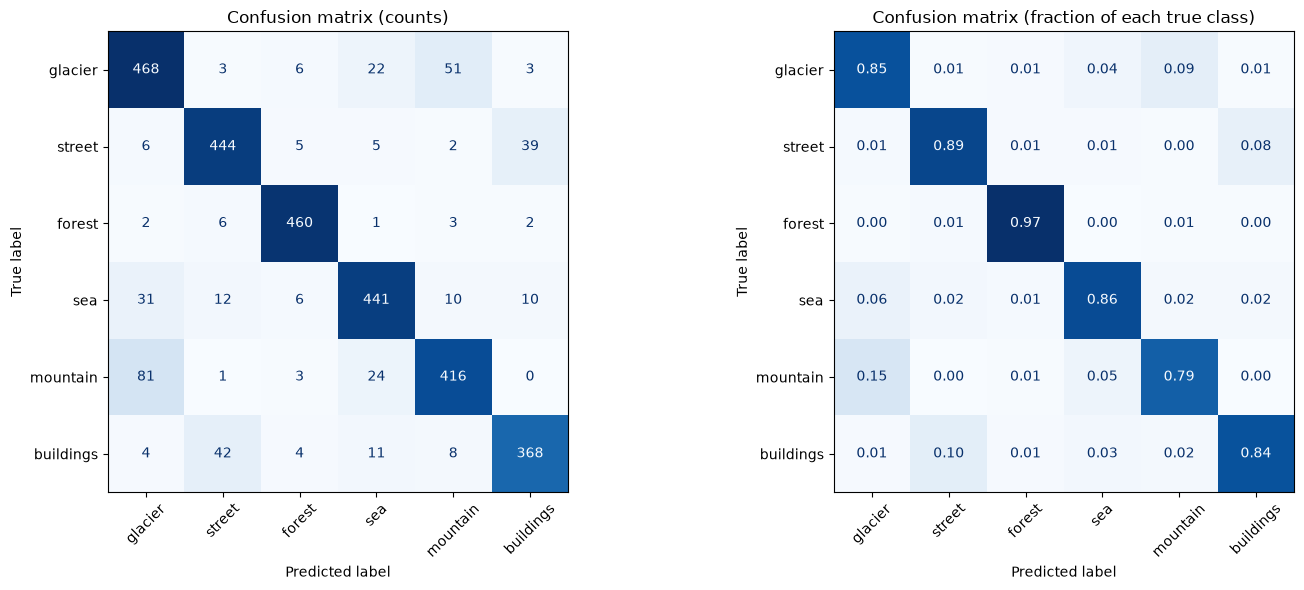

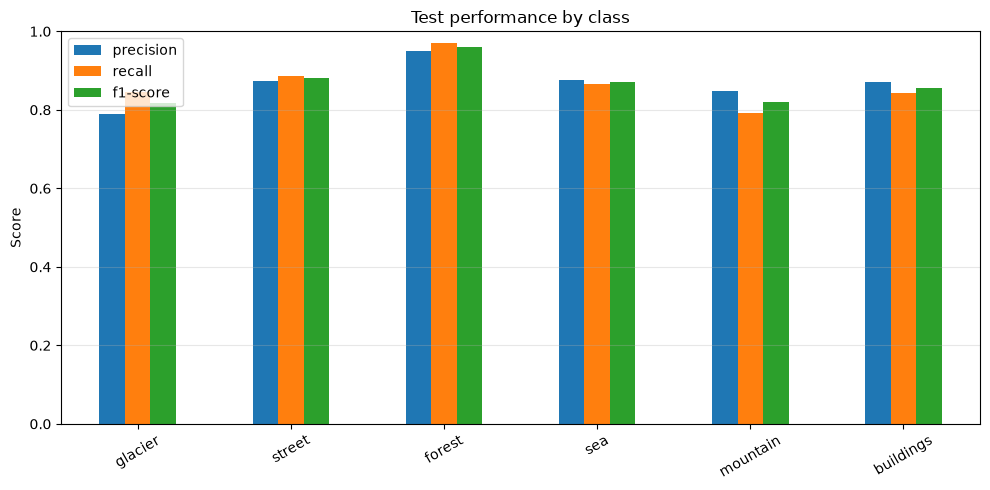

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, normalization, title in zip(
    axes, [None, "true"], ["Confusion matrix (counts)", "Confusion matrix (fraction of each true class)"]
):
    ConfusionMatrixDisplay.from_predictions(
        test_y, test_predictions, labels=class_ids, display_labels=class_names,
        normalize=normalization, cmap="Blues", ax=axis,
        values_format="d" if normalization is None else ".2f",
        xticks_rotation=45, colorbar=False,
    )
    axis.set_title(title)
fig.tight_layout()
fig.savefig(results_dir / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

report.loc[class_names, ["precision", "recall", "f1-score"]].plot.bar(figsize=(10, 5), ylim=(0, 1))
plt.title("Test performance by class")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "class_scores.png", dpi=150, bbox_inches="tight")
plt.show()

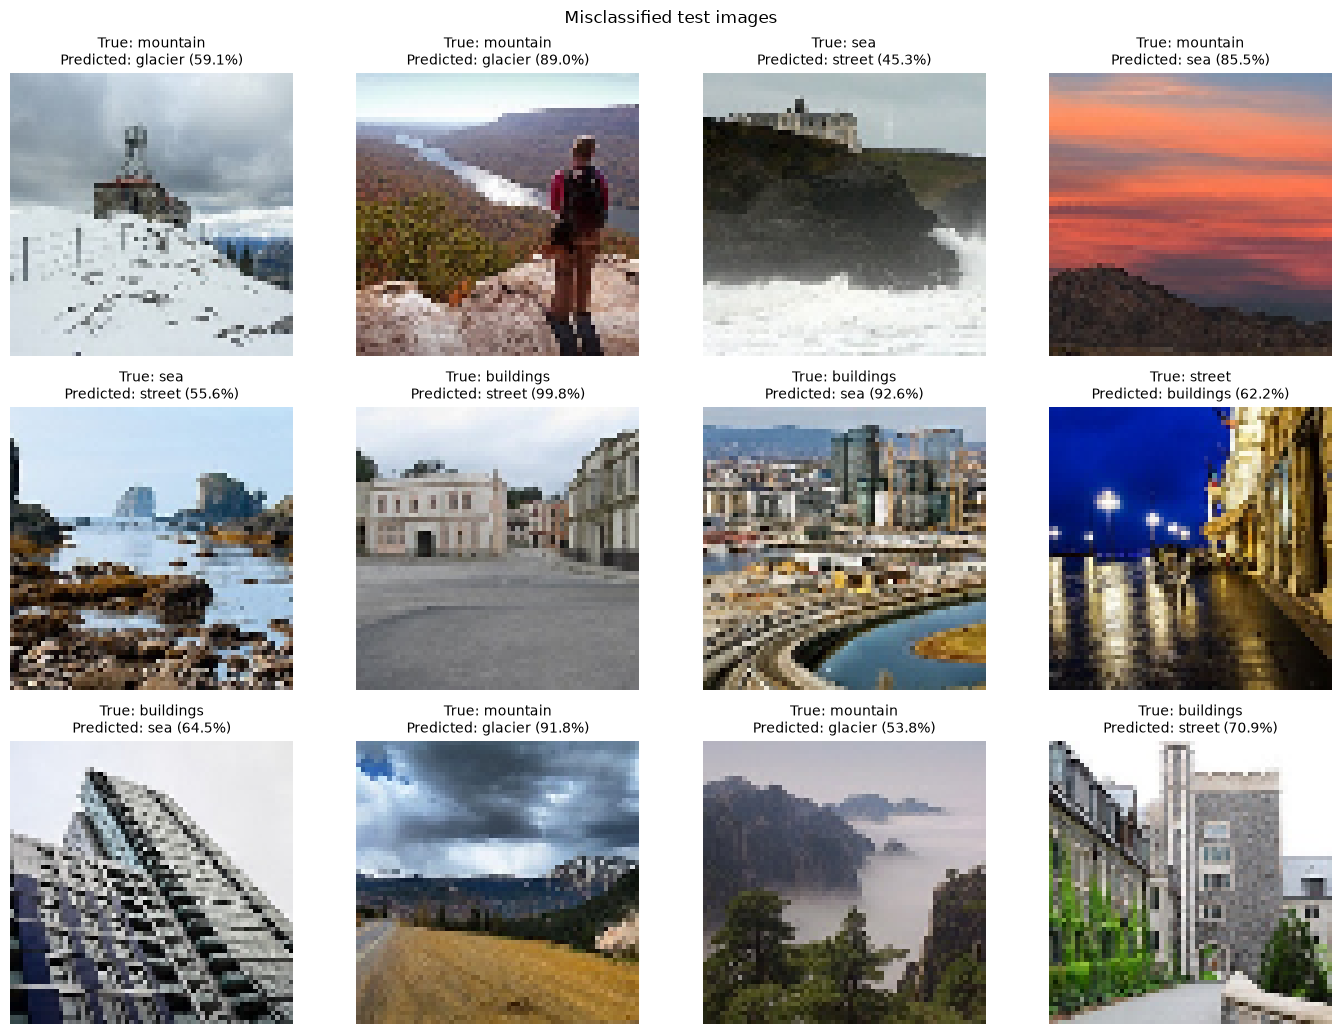

In [68]:
def plot_image_predictions(images, probabilities, indices, title, filename, true_labels=None):
    indices = np.asarray(indices)[:12]
    if len(indices) == 0:
        print("No images to display.")
        return
    rows = (len(indices) + 3) // 4
    fig, axes = plt.subplots(rows, 4, figsize=(14, 3.5 * rows), squeeze=False)
    for axis in axes.flat:
        axis.axis("off")
    for axis, index in zip(axes.flat, indices):
        predicted = int(probabilities[index].argmax())
        caption = f"Predicted: {class_names[predicted]} ({probabilities[index, predicted]:.1%})"
        if true_labels is not None:
            caption = f"True: {class_names[true_labels[index]]}\n" + caption
        axis.imshow(images[index].astype("uint8"))
        axis.set_title(caption, fontsize=10)
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(results_dir / filename, dpi=150, bbox_inches="tight")
    plt.show()


wrong_indices = np.flatnonzero(test_predictions != test_y)
rng = np.random.default_rng(42)
error_sample = rng.choice(wrong_indices, size=min(12, len(wrong_indices)), replace=False)
plot_image_predictions(
    test_x, test_probabilities, error_sample,
    "Misclassified test images", "test_errors.png", true_labels=test_y,
)

# Prediction

Run Testing first to load the model and plotting helper. Predict all images in
`dataset/seg_pred`, then display a random sample with predicted labels and softmax
scores. These images have no ground-truth labels, so accuracy cannot be calculated.

In [69]:
prediction_files = sorted(
    path for path in Path("dataset/seg_pred").iterdir()
    if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
)
if not prediction_files:
    raise FileNotFoundError("No prediction images found in dataset/seg_pred.")

prediction_images = []
for path in prediction_files:
    image = cv2.imread(str(path))
    if image is None:
        raise ValueError(f"Could not read image: {path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    prediction_images.append(cv2.resize(image, (64, 64)))

# Keep pixels in 0–255, matching training; do not divide by 255.
prediction_x = np.array(prediction_images, dtype=np.float32)
del prediction_images
prediction_probabilities = best_model.predict(prediction_x, batch_size=64, verbose=0)
prediction_ids = prediction_probabilities.argmax(axis=1)
prediction_results = pd.DataFrame({
    "filename": [path.name for path in prediction_files],
    "predicted_class": class_names[prediction_ids],
    "softmax_score": prediction_probabilities.max(axis=1),
})
prediction_results.to_csv(results_dir / "predictions.csv", index=False)
print(f"Predicted {len(prediction_results)} images. Results saved to {results_dir}")
prediction_results.head(12)

Predicted 7301 images. Results saved to fine_tune_best/final_l2/top5_20260928_183441_125531/best_model/evaluation


,filename,predicted_class,softmax_score
0,10004.jpg,street,0.725727
1,10005.jpg,mountain,0.985851
2,10012.jpg,street,0.984822
3,10013.jpg,mountain,0.999709
4,10017.jpg,mountain,0.990092
5,10021.jpg,forest,0.999979
6,1003.jpg,sea,0.999992
7,10034.jpg,glacier,1.000000
8,10038.jpg,sea,1.000000
9,10040.jpg,street,0.999951


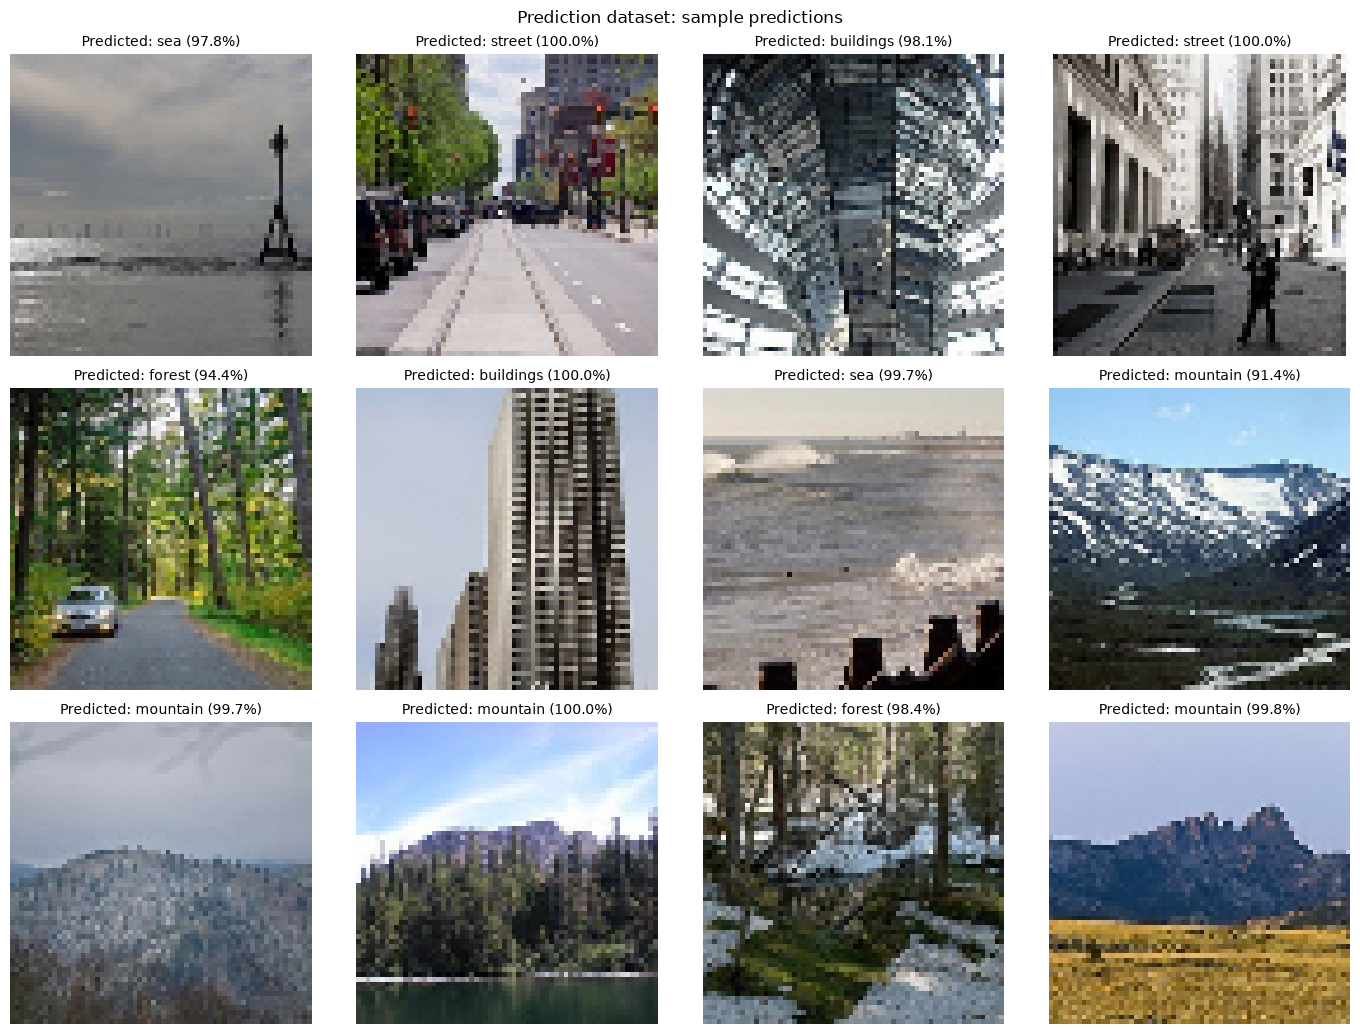

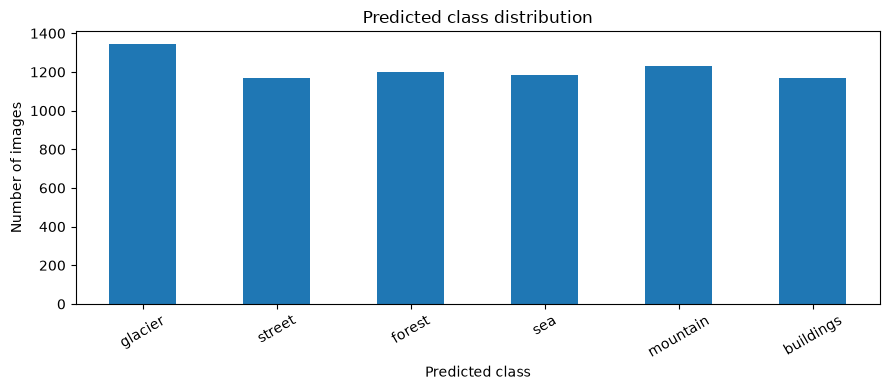

In [70]:
rng = np.random.default_rng(42)
sample_indices = rng.choice(len(prediction_x), size=min(12, len(prediction_x)), replace=False)
plot_image_predictions(
    prediction_x, prediction_probabilities, sample_indices,
    "Prediction dataset: sample predictions", "prediction_samples.png",
)

prediction_results["predicted_class"].value_counts().reindex(class_names, fill_value=0).plot.bar(figsize=(9, 4))
plt.title("Predicted class distribution")
plt.xlabel("Predicted class")
plt.ylabel("Number of images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(results_dir / "prediction_distribution.png", dpi=150, bbox_inches="tight")
plt.show()